# Laboratorio 1 - Exploración, preparación y regresión lineal

## 1. Comprensión y carga de los datos

En esta primera etapa se cargan los conjuntos de entrenamiento y prueba, junto con el diccionario de datos. El objetivo es comprender la estructura de los archivos antes de realizar cualquier transformación o corrección.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
datos = pd.read_csv("data/Datos Lab 1.csv")
datos_test = pd.read_csv("data/Datos Test Lab 1.csv")
diccionario = pd.read_excel("data/Diccionario de datos.xlsx")

In [9]:
print("Dimensiones entrenamiento:", datos.shape)
print("Dimensiones test:", datos_test.shape)
print("Dimensiones diccionario:", diccionario.shape)

Dimensiones entrenamiento: (2576, 27)
Dimensiones test: (364, 26)
Dimensiones diccionario: (27, 3)


In [11]:
datos.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [12]:
datos_test.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento
0,01.01.2016,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,0.8415,-0.8328,0.0927,173.6501,144,2016,1,invierno,January,S
1,02.01.2016,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.3604,1.1161,0.6688,30.9301,144,2016,2,invierno,January,NE
2,03.01.2016,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,1.2558,-0.7923,1.2638,122.0847,144,2016,3,invierno,January,SE
3,04.01.2016,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,1.4544,-1.6217,0.7020,156.5944,144,2016,4,invierno,January,SE
4,05.01.2016,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,0.7284,1.6549,0.7109,23.2458,144,2016,5,invierno,January,NE


In [13]:
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día...
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


In [14]:
columnas_entrenamiento = set(datos.columns)- set(datos_test.columns)
columnas_entrenamiento

{'temp_max_manana'}

### Variable objetivo

La variable objetivo del problema es `temp_max_manana`, correspondiente a la temperatura máxima del día siguiente en grados Celsius.

Por lo tanto, se trata de un problema de aprendizaje supervisado de regresión, ya que se dispone de una variable objetivo numérica continua en el conjunto de entrenamiento.

Eso está alineado con la definición del curso: una tarea de regresión busca aprender una función h: R^d -> R para predecir una respuesta continua.

In [15]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

In [16]:
datos_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              364 non-null    str    
 1   presion_media      364 non-null    float64
 2   presion_min        364 non-null    float64
 3   presion_max        364 non-null    float64
 4   presion_desv       364 non-null    float64
 5   humedad_media      364 non-null    float64
 6   humedad_min        364 non-null    float64
 7   humedad_max        364 non-null    float64
 8   humedad_desv       364 non-null    float64
 9   viento_media       364 non-null    float64
 10  viento_min         364 non-null    float64
 11  viento_max         364 non-null    float64
 12  viento_desv        364 non-null    float64
 13  rafaga_media       364 non-null    float64
 14  rafaga_min         364 non-null    float64
 15  rafaga_max         364 non-null    float64
 16  rafaga_desv        364 non-null    fl

### Descripción inicial de los conjuntos

El conjunto de entrenamiento contiene 2.576 observaciones y 27 variables, mientras que el conjunto de prueba contiene 364 observaciones y 26 variables.

La diferencia corresponde a `temp_max_manana`, que únicamente está disponible en el conjunto de entrenamiento y constituye la variable objetivo del problema.

Cada observación representa información meteorológica agregada de un día. Las características incluyen medidas de presión atmosférica, humedad, velocidad y dirección del viento, ráfagas e información temporal.

Debido a que `temp_max_manana` es una variable numérica continua, el problema corresponde a una tarea de regresión dentro del aprendizaje supervisado.

## 2. Exploración y diagnóstico de calidad de los datos

A partir de la descripción inicial, se realiza un perfilamiento más detallado del conjunto de entrenamiento. El objetivo es comprender la distribución de las variables e identificar problemas de completitud, unicidad, consistencia y validez antes de realizar cualquier corrección.

En esta etapa los problemas únicamente se diagnostican. Las modificaciones sobre los datos se realizarán posteriormente en la etapa de preparación.

In [17]:
#2.1 — Estadísticas descriptivas

# Obtener estadísticas descriptivas de las variables numéricas.
# Revisar las variables categóricas mediante frecuencias.
# Comparar los resultados con el diccionario de datos.
# Identificar valores o escalas que parezcan inconsistentes.

display(datos.describe())
display(datos.describe(include='object'))

# Al comparar con el diccionario de datos resaltan dos problemas de escala/validez
# que se profundizarán en 2.6: presion_media alcanza valores cercanos a 9800-9900
# (mbar), muy por encima del resto de observaciones (~950-1015), y humedad_media /
# humedad_min presentan un mínimo cercano a 0 pese a definirse como porcentaje
# (0-100), lo que sugiere que algunos registros quedaron en escala de proporción.


,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


C:\Users\Alejandro Zambrano\AppData\Local\Temp\ipykernel_17132\2199386499.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(datos.describe(include='object'))


,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2009-01-22,primavera,May,SO
freq,2,517,127,695


### 2.2. Completitud

Se analiza la presencia de valores faltantes en cada variable del conjunto de entrenamiento. En esta sección únicamente se cuantificará el problema; la estrategia de tratamiento se determinará durante la preparación de los datos.

In [18]:
faltantes = datos.isna().sum()

porcentaje_faltantes = (
    datos.isna().mean() * 100
).round(2)

resumen_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": porcentaje_faltantes
})

resumen_faltantes = (
    resumen_faltantes
    .sort_values("porcentaje", ascending=False)
)

display(resumen_faltantes)

# Variables con al menos un valor faltante.
resumen_faltantes[resumen_faltantes["faltantes"] > 0]


,faltantes,porcentaje
temp_max_manana,95,3.69
viento_min,91,3.53
mes,88,3.42
estacion_anio,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
presion_desv,80,3.11
humedad_min,80,3.11


,faltantes,porcentaje
temp_max_manana,95,3.69
viento_min,91,3.53
mes,88,3.42
estacion_anio,88,3.42
anio,86,3.34
humedad_max,86,3.34
viento_media,86,3.34
viento_max,81,3.14
presion_desv,80,3.11
humedad_min,80,3.11


### 2.3. Unicidad

Se verifica si existen registros repetidos en el conjunto de entrenamiento. Los duplicados pueden representar errores de almacenamiento o distintas observaciones reales, por lo que no deben eliminarse automáticamente sin analizar su significado.

Se distinguen dos situaciones que exigen tratamientos distintos: filas **completamente idénticas** (donde eliminar una copia no pierde información) y registros que **comparten la fecha pero difieren en algún valor** (donde hace falta una regla explícita para decidir cuál conservar).

In [19]:
#2.3 — Unicidad

# Filas completamente duplicadas: todas las columnas coinciden.
print("Filas completamente duplicadas:", datos.duplicated(keep=False).sum(),
      "| copias sobrantes:", datos.duplicated().sum())

# Fechas repetidas, ignorando registros con fecha faltante: dos fechas ausentes no
# son una fecha "repetida".
fecha_dt = pd.to_datetime(datos["fecha"], format="%Y-%m-%d", errors="coerce")
repetida = fecha_dt.notna() & fecha_dt.duplicated(keep=False)
print("Registros que comparten fecha con otro:", repetida.sum())

fechas_repetidas = datos[repetida].assign(_fecha=fecha_dt[repetida]).sort_values("_fecha")
display(fechas_repetidas.drop(columns="_fecha"))

# ¿Los registros que comparten fecha son realmente idénticos? Para cada fecha
# repetida se cuenta en cuántas columnas los registros toman valores distintos.
discrepancias = (
    fechas_repetidas
    .groupby("_fecha")
    .apply(lambda g: int((g.nunique(dropna=False) > 1).sum()))
)
print("\nDistribución de columnas con valores distintos dentro de cada fecha repetida:")
print(discrepancias.value_counts().sort_index().rename("nº de fechas"))

print("\nValores faltantes en cada registro repetido:",
      sorted(fechas_repetidas.drop(columns="_fecha").isna().sum(axis=1).unique().tolist()))

# Conclusión: solo una parte de las fechas repetidas corresponde a filas idénticas;
# el resto difiere en una o varias columnas y en su número de valores faltantes.
# Por lo tanto no basta con drop_duplicates(): en 3.1 se definirá una regla
# explícita para escoger entre registros que comparten fecha pero no son iguales.
# No se elimina ningún registro en esta etapa.

Filas completamente duplicadas: 8 | copias sobrantes: 4
Registros que comparten fecha con otro: 36


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
2563,2009-01-22,9784.115000,971.48000,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770000
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.29080,...,1.1131,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,NaN,0.4668,23.7431,144.0,NaN,122.0,primavera,october,NaN,20.890000
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.84440,...,1.0611,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.53492,...,-0.6218,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.53492,...,-0.6218,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.70860,...,0.7872,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000



Distribución de columnas con valores distintos dentro de cada fecha repetida:
0    4
1    7
2    3
3    3
4    1
Name: nº de fechas, dtype: int64

Valores faltantes en cada registro repetido: [0, 1, 2, 3, 4]


### 2.4. Consistencia de variables categóricas

Se revisan las categorías observadas en las variables de texto para detectar diferentes representaciones de una misma categoría, errores de escritura o valores incompatibles con el significado definido en el diccionario.

In [20]:
#2.4 — Consistencia de variables categóricas

def normalizar_texto(serie):
    """Quita espacios en los extremos y pasa a minúsculas, para poder comparar
    entre sí representaciones equivalentes de una misma categoría."""
    return serie.astype(str).str.strip().str.lower()


for col in ["estacion_anio", "mes", "sector_viento"]:
    print(f"--- {col}: {datos[col].nunique(dropna=True)} categorías únicas (crudas) ---")
    print(datos[col].value_counts(dropna=False))

    normalizado = normalizar_texto(datos[col].dropna())
    print(f"--- {col}: {normalizado.nunique()} categorías tras normalizar (sin espacios, en minúsculas) ---")
    print(sorted(normalizado.unique()))
    print()

# Hallazgos:
# - sector_viento: las 33 categorías crudas colapsan en 8 puntos cardinales reales
#   (N, S, E, O, NE, NO, SE, SO) una vez normalizadas; todas son mapeables al
#   dominio esperado (sin valores fuera de dominio).
# - mes: 61 categorías crudas (mezcla de español/inglés, nombre completo/abreviado,
#   mayúsculas/minúsculas) que sí corresponden todas a alguno de los 12 meses,
#   pero con muchísima variación de escritura.
# - estacion_anio: además de mezclar español/inglés, mayúsculas/minúsculas, tildes
#   ("otoño" / "otono") y errores de escritura (p. ej. "Inverano", "invernio",
#   "berano", "verno"), contiene categorías que no corresponden a ninguna estación
#   real del dominio ("East", "Estacion_Desconocida", "VERANO_INVIERNO").
#
# La normalización se limita a espacios y mayúsculas/minúsculas; las variantes
# restantes (incluidas las tildes) se resuelven con diccionarios explícitos que
# enumeran cada forma observada, de modo que ninguna categoría se transforma sin
# haber sido revisada antes.

--- estacion_anio: 28 categorías únicas (crudas) ---
estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
NaN                      88
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64
--- estacion_anio: 19 categorías tras normalizar (sin espacios, en minúsculas) ---
['autumn', '

### 2.5. Consistencia de la información temporal

El conjunto contiene distintas representaciones temporales: `fecha`, `anio`, `dia_del_anio`, `mes` y `estacion_anio`.

Se verificará que estas variables representen de manera coherente la misma fecha y se analizará si algunas contienen información redundante. Como referencia se toma `fecha`, por ser la representación más completa y la única de la que las demás pueden derivarse.

Del conjunto de prueba final se revisa **únicamente la compatibilidad técnica del formato de fecha**, para poder aplicarle después exactamente la misma regla determinística de conversión. No se calcula sobre él ninguna estadística ni se examina su contenido.

In [21]:
#2.5 — Consistencia de la información temporal

# Formato de fecha usado en cada conjunto.
print("Formato en entrenamiento (ejemplos):", datos["fecha"].dropna().head(3).tolist())
print("Formato en el conjunto de prueba final (ejemplos):", datos_test["fecha"].dropna().head(3).tolist())
# -> entrenamiento usa 'AAAA-MM-DD' (ISO) y el conjunto de prueba usa 'DD.MM.AAAA'.
# Se documenta la diferencia de formato; no se modifica ningún dato en esta etapa
# (la conversión se hará en la preparación de los datos).

fecha_train = pd.to_datetime(datos["fecha"], format="%Y-%m-%d", errors="coerce")
fecha_test = pd.to_datetime(datos_test["fecha"], format="%d.%m.%Y", errors="coerce")

print("Fechas de entrenamiento no interpretables con el formato detectado:",
      ((datos["fecha"].notna()) & (fecha_train.isna())).sum())
print("Fechas de prueba no interpretables con el formato detectado:",
      ((datos_test["fecha"].notna()) & (fecha_test.isna())).sum())

# Comparar fecha con anio y con dia_del_anio.
mask_anio = fecha_train.notna() & datos["anio"].notna()
print("Desacuerdos entre fecha y anio:",
      (fecha_train[mask_anio].dt.year != datos.loc[mask_anio, "anio"]).sum(), "de", mask_anio.sum())

mask_dia = fecha_train.notna() & datos["dia_del_anio"].notna()
print("Desacuerdos entre fecha y dia_del_anio:",
      (fecha_train[mask_dia].dt.dayofyear != datos.loc[mask_dia, "dia_del_anio"]).sum(), "de", mask_dia.sum())

# Comparar fecha con mes (normalizando nombres completos y abreviados, en español e inglés).
meses_map = {
    "enero": 1, "ene": 1, "jan": 1, "january": 1,
    "febrero": 2, "feb": 2, "february": 2,
    "marzo": 3, "mar": 3, "march": 3,
    "abril": 4, "abr": 4, "apr": 4, "april": 4,
    "mayo": 5, "may": 5,
    "junio": 6, "jun": 6, "june": 6,
    "julio": 7, "jul": 7, "july": 7,
    "agosto": 8, "ago": 8, "aug": 8, "august": 8,
    "septiembre": 9, "setiembre": 9, "sep": 9, "sept": 9, "september": 9,
    "octubre": 10, "oct": 10, "october": 10,
    "noviembre": 11, "nov": 11, "november": 11,
    "diciembre": 12, "dic": 12, "dec": 12, "december": 12,
}
mes_normalizado = normalizar_texto(datos["mes"].dropna())
mes_num = mes_normalizado.map(meses_map).reindex(datos.index)
print("Valores de mes que no corresponden a ningún nombre de mes conocido:",
      sorted(mes_normalizado[mes_normalizado.map(meses_map).isna()].unique().tolist()))

mask_mes = fecha_train.notna() & mes_num.notna()
print("Desacuerdos entre fecha y mes:",
      (fecha_train[mask_mes].dt.month != mes_num[mask_mes]).sum(), "de", int(mask_mes.sum()))

# Comparar fecha con estacion_anio. La estación esperada NO se aprende de los datos:
# se usa la convención meteorológica del hemisferio norte, que es donde se ubica la
# estación de Jena (Alemania) de la que provienen los registros.
estacion_map = {
    "invierno": "invierno", "inverano": "invierno", "invernio": "invierno", "winter": "invierno",
    "primavera": "primavera", "primaveraa": "primavera", "primav": "primavera", "spring": "primavera",
    "verano": "verano", "berano": "verano", "verno": "verano", "summer": "verano",
    "otono": "otono", "otoño": "otono", "autumn": "otono", "fall": "otono",
}
convencion_estaciones = {
    12: "invierno", 1: "invierno", 2: "invierno",
    3: "primavera", 4: "primavera", 5: "primavera",
    6: "verano", 7: "verano", 8: "verano",
    9: "otono", 10: "otono", 11: "otono",
}

estacion_canon = normalizar_texto(datos["estacion_anio"].dropna()).map(estacion_map).reindex(datos.index)
print("Registros cuya estacion_anio no corresponde a ninguna estación del dominio:",
      int(datos["estacion_anio"].notna().sum() - estacion_canon.notna().sum()))

mask_est = fecha_train.notna() & estacion_canon.notna()
esperado = fecha_train[mask_est].dt.month.map(convencion_estaciones)
print("Desacuerdos entre estacion_anio y la estación que corresponde a la fecha:",
      (estacion_canon[mask_est] != esperado).sum(), "de", int(mask_est.sum()))

# Conclusión: anio y dia_del_anio son plenamente consistentes con fecha (0
# desacuerdos), por lo que pueden usarse directamente. mes y estacion_anio, en
# cambio, presentan una tasa alta de desacuerdo con la fecha real y son derivables
# de ella, por lo que resultan redundantes y menos confiables que fecha.

Formato en entrenamiento (ejemplos): ['2009-01-01', '2009-01-02', '2009-01-03']
Formato en el conjunto de prueba final (ejemplos): ['01.01.2016', '02.01.2016', '03.01.2016']
Fechas de entrenamiento no interpretables con el formato detectado: 0
Fechas de prueba no interpretables con el formato detectado: 0
Desacuerdos entre fecha y anio: 0 de 2421
Desacuerdos entre fecha y dia_del_anio: 0 de 2437
Valores de mes que no corresponden a ningún nombre de mes conocido: []
Desacuerdos entre fecha y mes: 1136 de 2417
Registros cuya estacion_anio no corresponde a ninguna estación del dominio: 171
Desacuerdos entre estacion_anio y la estación que corresponde a la fecha: 456 de 2249


### 2.6. Validez de las variables numéricas

Se revisará si los valores numéricos respetan los rangos y unidades definidos en el diccionario.

Los valores extremos no se considerarán automáticamente errores. Primero se distinguirá entre observaciones poco frecuentes pero plausibles y valores incompatibles con el dominio de la variable.

In [22]:
#2.6 — Validez de las variables numéricas

numeric_cols = datos.select_dtypes("number").columns
display(datos[numeric_cols].agg(["min", "max"]).T)

# Contrastando estos rangos con las unidades y descripciones del diccionario de
# datos, se identifican valores incompatibles con el dominio físico esperado.
# Ninguno se corrige ni se elimina en esta etapa: solo se documentan como
# candidatos a tratar en la preparación de los datos.

print("presion_media > 2000 mbar (posible error de escala/punto decimal):",
      (datos["presion_media"] > 2000).sum())

print("humedad_media <= 1 (posible proporción en vez de porcentaje):",
      (datos["humedad_media"] <= 1).sum())
print("humedad_min <= 1 (mismo problema de escala):",
      (datos["humedad_min"] <= 1).sum())
print("humedad_min > 100% (fuera del dominio 0-100):",
      (datos["humedad_min"] > 100).sum())

print("rafaga_desv < 0 (una desviación estándar no puede ser negativa):",
      (datos["rafaga_desv"] < 0).sum())
print("rafaga_min == -9999 (posible código centinela de dato faltante):",
      (datos["rafaga_min"] == -9999).sum())

print("viento_desv > 100 (magnitud implausible para una desviación de velocidad de viento):",
      (datos["viento_desv"] > 100).sum())
print("viento_norte con magnitud extrema (< -100):",
      (datos["viento_norte"] < -100).sum())

print("direccion_viento fuera de [0, 360):",
      ((datos["direccion_viento"] < 0) | (datos["direccion_viento"] >= 360)).sum())


,min,max
presion_media,948.996000,9939.918000
presion_min,913.600000,1012.320198
presion_max,951.940000,1013.940000
presion_desv,0.226900,12.397500
humedad_media,0.004663,100.000000
humedad_min,0.237700,103.311405
humedad_max,27.020000,100.000000
humedad_desv,0.000000,26.341600
viento_media,0.000000,24.753600
viento_min,0.000000,45.184956


presion_media > 2000 mbar (posible error de escala/punto decimal): 6
humedad_media <= 1 (posible proporción en vez de porcentaje): 776
humedad_min <= 1 (mismo problema de escala): 621
humedad_min > 100% (fuera del dominio 0-100): 23
rafaga_desv < 0 (una desviación estándar no puede ser negativa): 258
rafaga_min == -9999 (posible código centinela de dato faltante): 1
viento_desv > 100 (magnitud implausible para una desviación de velocidad de viento): 132
viento_norte con magnitud extrema (< -100): 1
direccion_viento fuera de [0, 360): 0


### 2.7. Distribuciones y relaciones entre variables

Se estudiará la forma de las distribuciones y las relaciones entre las características y la variable objetivo con el propósito de comprender mejor el problema y formular hipótesis antes de construir los modelos.

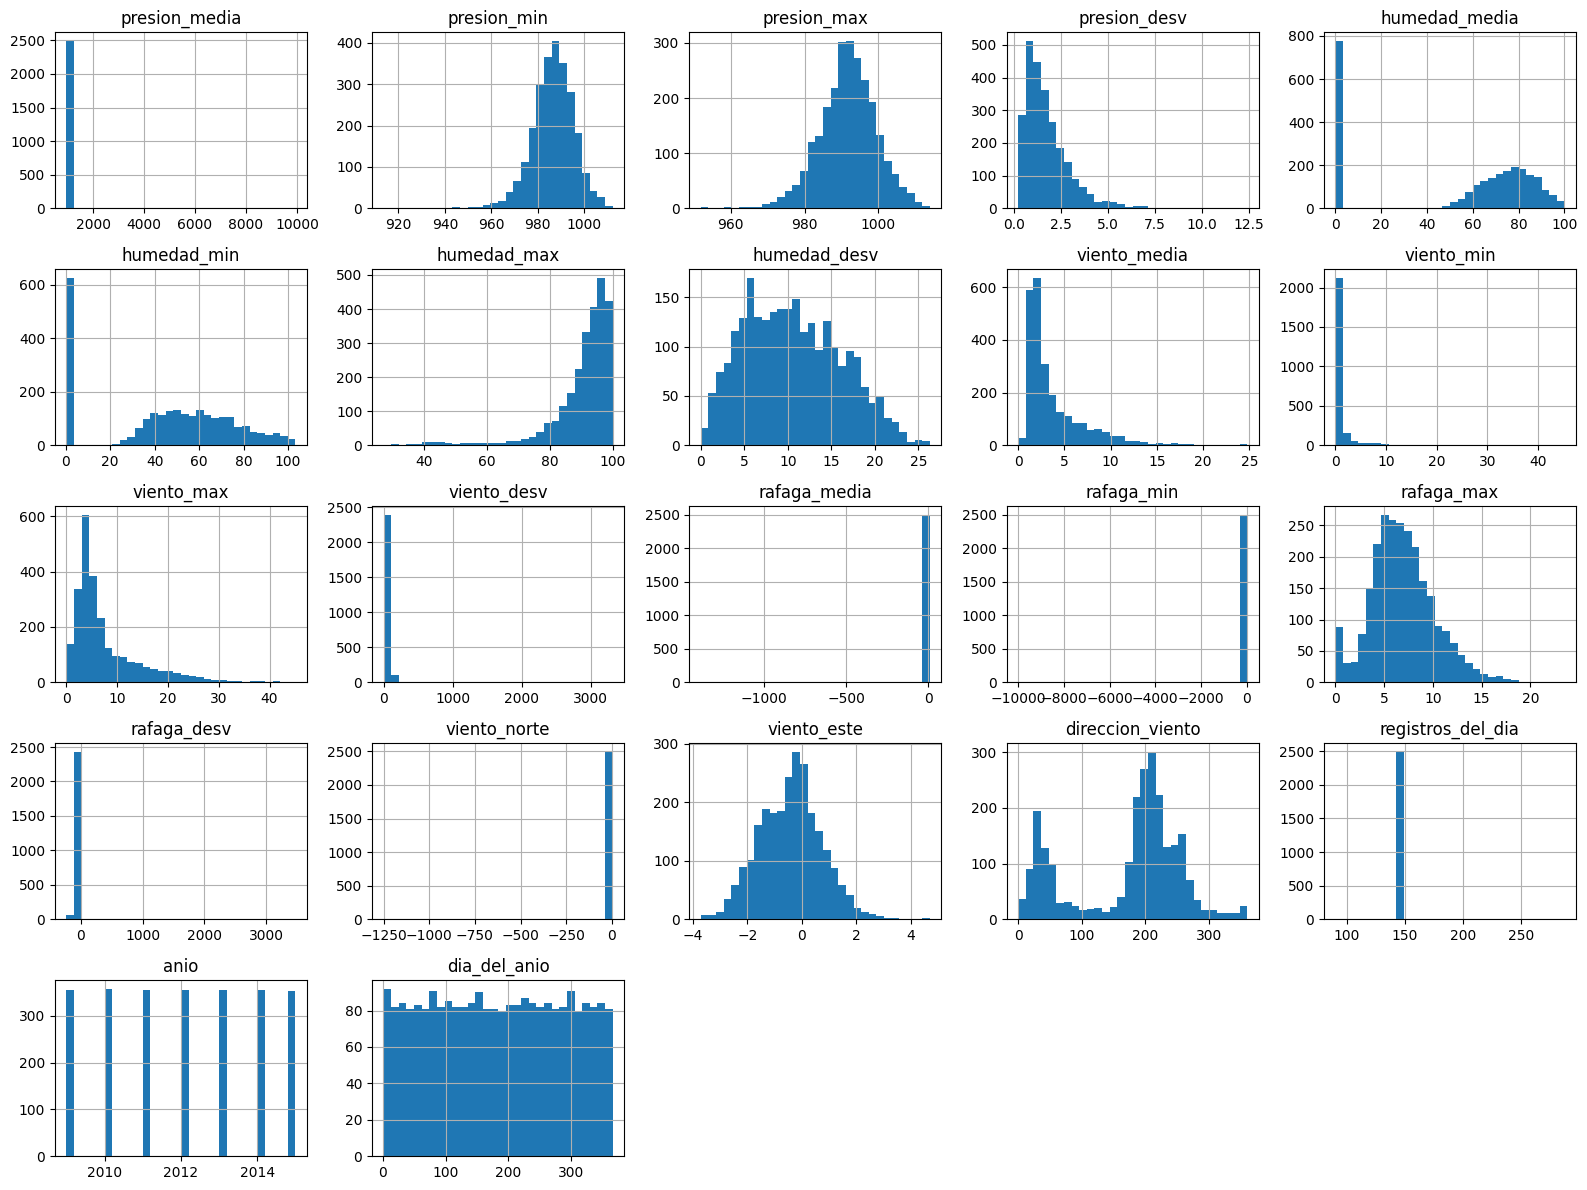

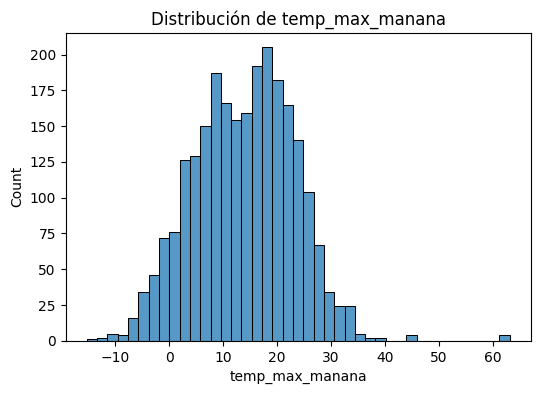

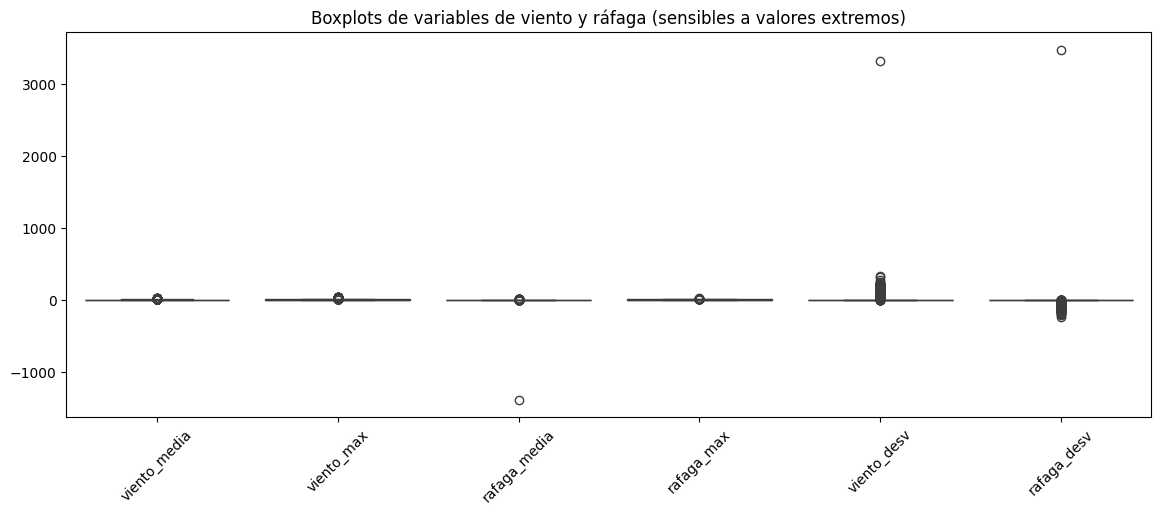

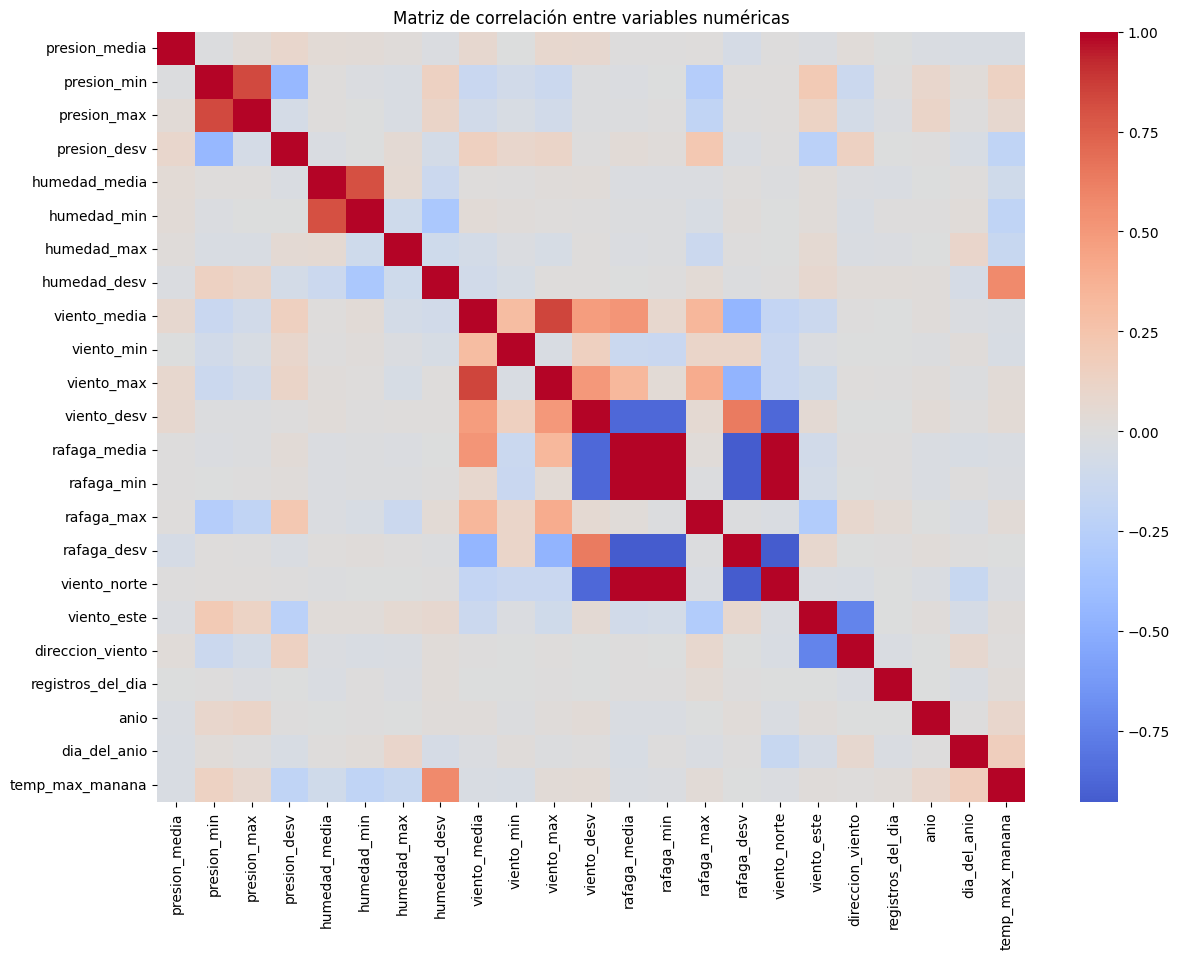

temp_max_manana      1.000000
humedad_desv         0.571459
dia_del_anio         0.165812
presion_min          0.141860
anio                 0.092718
presion_max          0.070861
viento_desv          0.040129
viento_max           0.031348
rafaga_max           0.030527
registros_del_dia    0.025923
viento_este          0.015941
direccion_viento     0.007824
rafaga_desv         -0.007027
rafaga_min          -0.019087
viento_norte        -0.020881
rafaga_media        -0.024158
presion_media       -0.032249
viento_media        -0.035994
viento_min          -0.039749
humedad_media       -0.098139
humedad_max         -0.155211
presion_desv        -0.199890
humedad_min         -0.203226
Name: temp_max_manana, dtype: float64

In [23]:
#2.7 — Distribuciones y relaciones entre variables

numeric_cols = datos.select_dtypes("number").columns.drop("temp_max_manana")

datos[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(datos["temp_max_manana"].dropna())
plt.title("Distribución de temp_max_manana")
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(data=datos[["viento_media", "viento_max", "rafaga_media", "rafaga_max",
                         "viento_desv", "rafaga_desv"]])
plt.xticks(rotation=45)
plt.title("Boxplots de variables de viento y ráfaga (sensibles a valores extremos)")
plt.show()

plt.figure(figsize=(14, 10))
correlaciones = datos.select_dtypes("number").corr()
sns.heatmap(correlaciones, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

correlaciones["temp_max_manana"].sort_values(ascending=False)

# temp_max_manana muestra una distribución aproximadamente simétrica. Los grupos
# de variables de presión (media/min/max/desv) y de humedad están fuertemente
# correlacionados entre sí, lo que sugiere redundancia informativa entre ellas;
# lo mismo ocurre con viento_media/viento_max y rafaga_media/rafaga_max.
#
# Nota: estas correlaciones se calculan sobre todo el conjunto etiquetado y se usan
# únicamente para describir y entender los datos. Ninguna decisión de modelado
# (selección de variables, umbrales, hiperparámetros) se toma a partir de ellas,
# precisamente porque incluyen observaciones que después quedarán en el conjunto de
# validación.

### 2.8. Hallazgos de la exploración

Los resultados anteriores se resumen para establecer qué correcciones y transformaciones serán necesarias antes del modelado.

Hallazgos de la exploración (conjunto de entrenamiento):

- **Completitud:** todas las variables presentan valores faltantes, entre ~2.4% y
  ~3.7% de las observaciones; no hay una variable con un porcentaje extremo de
  faltantes que obligue a descartarla por completo.
- **Unicidad:** existen 8 filas completamente duplicadas (4 copias sobrantes) y 36
  registros que comparten fecha con otro (18 fechas repetidas). Solo 4 de esas
  fechas corresponden a filas idénticas; las 14 restantes difieren entre 1 y 4
  columnas y tienen distinto número de valores faltantes. Con los datos disponibles
  no es posible determinar si se trata de reingresos del mismo dato o de mediciones
  distintas, ni cuál de los dos registros es el correcto: el conjunto no incluye
  marca de tiempo intradía ni indicador de versión. En 3.1 se define una regla
  explícita y determinística, y se documenta su limitación.
- **Consistencia categórica:** `estacion_anio`, `mes` y `sector_viento` repiten la
  misma categoría escrita de múltiples formas (mayúsculas/minúsculas,
  español/inglés, abreviaturas, tildes, espacios); `estacion_anio` además contiene
  171 registros con valores que no corresponden a ninguna estación real ("East",
  "Estacion_Desconocida", "VERANO_INVIERNO").
- **Consistencia temporal:** `anio` y `dia_del_anio` son plenamente coherentes con
  `fecha` (0 desacuerdos). `mes` y `estacion_anio`, en cambio, contradicen la fecha
  real en ~47% y ~20% de los casos comparables y son derivables directamente de
  ella, por lo que resultan redundantes y menos confiables.
- **Validez numérica:** se encontraron valores incompatibles con el dominio físico
  esperado: `presion_media` por encima de 2000 mbar en 6 registros (compatible con
  un error de escala/punto decimal, ya que al dividir por 10 caen dentro del rango
  normal), `humedad_media`/`humedad_min` en escala de proporción (0-1) en vez de
  porcentaje en cientos de registros, `humedad_min` por encima de 100% en 23
  registros pero por un margen pequeño (entre 0.3 y 3.31 puntos porcentuales),
  desviaciones estándar negativas en `rafaga_desv` (258 registros, imposible por
  definición), un único registro con `rafaga_min = -9999` (compatible con un código
  centinela de dato faltante), y un registro con magnitud extrema en `viento_norte`
  junto con 132 registros con `viento_desv > 100` sin un patrón de escala igual de
  claro.
- **Distribuciones y relaciones:** no se observan anomalías evidentes en la
  distribución de `temp_max_manana` a partir del histograma y de las estadísticas
  descriptivas. Su correlación lineal con el resto de variables es en general baja,
  salvo `humedad_desv`, que se destaca por encima de las demás (≈0.57);
  `dia_del_anio`, `presion_min`/`presion_max` y algunas variables de humedad
  muestran correlaciones moderadas (entre ±0.10 y ±0.20). Dentro de cada grupo
  (presión, humedad, viento/ráfaga) las variables están fuertemente correlacionadas
  entre sí, lo que indica redundancia informativa dentro de cada grupo. Varias
  variables (`viento_desv`, `rafaga_desv`, `viento_norte`) conservan valores
  extremos tras la limpieza, lo que condiciona la estrategia de imputación.
- **Implicaciones para la preparación:** la baja correlación *lineal* de
  `dia_del_anio` con el objetivo no significa que la información temporal sea poco
  útil: el ciclo anual de temperatura no es monótono (enero y diciembre son
  igualmente fríos), por lo que un único coeficiente lineal sobre el día del año no
  puede capturarlo. Esta observación motiva la estrategia de ingeniería de
  características del Modelo 2 (sección 4.2).

> Estas conclusiones describen lo observado en los datos. Cuando no es posible
> determinar la causa de una anomalía a partir de la evidencia disponible, se
> documenta como tal en lugar de afirmar un origen concreto.

## 3. Preparación de los datos

La preparación se realiza a partir de los problemas identificados durante la exploración. Cada transformación se justificará de acuerdo con el tipo de variable, el porcentaje de datos afectados y su significado dentro del problema.

Para evitar fuga de datos, las transformaciones que requieran estimar parámetros a partir de los datos se ajustarán únicamente utilizando el conjunto de entrenamiento.

### 3.1. Corrección de consistencia y validez

Primero se aplicarán únicamente transformaciones determinísticas, es decir, aquellas que dependen de reglas conocidas del dominio y no de estadísticas calculadas a partir de la muestra.

La sección vuelve a leer los archivos originales antes de corregirlos, de modo que la preparación pueda re-ejecutarse tantas veces como sea necesario partiendo siempre del mismo estado y sin acumular transformaciones sobre transformaciones.

In [24]:
#3.1 — Corrección de consistencia y validez

# Se parte nuevamente de los archivos originales para que esta sección sea
# reproducible: al re-ejecutarla, las correcciones se aplican siempre sobre los
# datos crudos y nunca sobre datos ya corregidos.
datos = pd.read_csv("data/Datos Lab 1.csv")
datos_test = pd.read_csv("data/Datos Test Lab 1.csv")

# Diccionarios de corrección construidos a partir de las categorías observadas en
# 2.4: mapean cada variante encontrada a una única categoría canónica. Los valores
# no contemplados (por ejemplo, categorías fuera de dominio) quedan como faltantes,
# ya que no existe una regla de dominio que permita saber cuál era su valor correcto.
sector_map = {
    "n": "N", "norte": "N", "north": "N",
    "s": "S", "sur": "S", "south": "S",
    "e": "E", "este": "E", "east": "E",
    "o": "O", "oeste": "O", "west": "O",
    "ne": "NE", "noreste": "NE", "northeast": "NE",
    "no": "NO", "noroeste": "NO", "northwest": "NO",
    "se": "SE", "sureste": "SE", "southeast": "SE",
    "so": "SO", "suroeste": "SO", "southwest": "SO",
}


def normalizar_categoria(serie, mapa):
    """Normaliza el texto (2.4) y lo mapea a una categoría canónica; conserva como
    faltante lo que ya era faltante o no corresponde a ninguna categoría válida."""
    return normalizar_texto(serie.dropna()).map(mapa).reindex(serie.index)


def corregir_dataset(df, formato_fecha):
    df = df.copy()

    # Convertir fecha al tipo temporal adecuado, según el formato de cada conjunto (2.5).
    df["fecha"] = pd.to_datetime(df["fecha"], format=formato_fecha, errors="coerce")

    # Normalizar las representaciones equivalentes de sector_viento.
    df["sector_viento"] = normalizar_categoria(df["sector_viento"], sector_map)

    # Corregir únicamente los valores inválidos que tienen una regla de dominio
    # clara y justificable (2.6); el resto se deja intacto.
    df.loc[df["presion_media"] > 2000, "presion_media"] /= 10   # error de escala/punto decimal
    df.loc[df["humedad_media"] <= 1, "humedad_media"] *= 100    # proporción (0-1) en vez de porcentaje
    df.loc[df["humedad_min"] <= 1, "humedad_min"] *= 100

    # El diccionario define la humedad relativa como un porcentaje, es decir, en el
    # intervalo [0, 100]. Los 23 valores que lo superan lo hacen por un margen
    # pequeño (entre 0.3 y 3.31 puntos porcentuales), compatible con un error de
    # redondeo o de calibración del sensor y no con un error de escala. Por eso se
    # recortan al máximo válido con clip() en vez de descartarlos o de tratarlos
    # como faltantes: el valor real está, con casi total seguridad, muy cerca de
    # 100. Si el exceso hubiera sido de un orden de magnitud, este criterio no
    # sería aplicable.
    df["humedad_min"] = df["humedad_min"].clip(upper=100)

    df.loc[df["rafaga_min"] == -9999, "rafaga_min"] = np.nan    # código centinela de dato faltante
    df["rafaga_desv"] = df["rafaga_desv"].abs()                 # una desviación estándar no puede ser negativa

    # viento_desv > 100 y viento_norte < -100 (2.6) no muestran un patrón de escala
    # tan claro como presion_media (no hay evidencia de un factor fijo como /10),
    # por lo que no se modifican: quedan documentados como valores extremos a
    # vigilar, no como errores corregibles con una regla simple.

    # mes y estacion_anio no se normalizan: en 2.5 se comprobó que contradicen la
    # fecha real en una proporción alta de registros y que son derivables de ella,
    # de modo que se reconstruyen desde fecha en 3.3 en lugar de repararse.

    return df


datos = corregir_dataset(datos, formato_fecha="%Y-%m-%d")
datos_test = corregir_dataset(datos_test, formato_fecha="%d.%m.%Y")

print("sector_viento tras corregir:", sorted(datos["sector_viento"].dropna().unique()))
print("presion_media máximo tras corregir:", round(datos["presion_media"].max(), 2))
print("humedad_min rango tras corregir:",
      round(datos["humedad_min"].min(), 2), "-", round(datos["humedad_min"].max(), 2))

# --- Unicidad -------------------------------------------------------------
# Se aplica solo al conjunto de entrenamiento: el conjunto de prueba final debe
# conservar todas sus filas porque hay que entregar una predicción por registro.
#
# Paso 1: filas completamente idénticas. Eliminar una copia no descarta ninguna
# información, porque los dos registros son indistinguibles.
antes = len(datos)
datos = datos.drop_duplicates()
print(f"\nFilas idénticas eliminadas: {antes - len(datos)} (de {antes} a {len(datos)})")

# Paso 2: registros que comparten fecha pero no son idénticos (2.3). Como cada
# observación representa un día y la variable objetivo es la temperatura del día
# siguiente, no pueden coexistir dos registros para la misma fecha; además, dejar
# ambos haría que un mismo día pudiera quedar repartido entre entrenamiento y
# validación, inflando artificialmente el desempeño medido.
#
# El conjunto no incluye ninguna marca de tiempo dentro del día ni un indicador de
# versión, de modo que NO es posible determinar cuál de los dos registros es el
# correcto ni cuál es el más reciente. Ante esa limitación se aplica el único
# criterio observable y justificable con los datos disponibles: conservar el
# registro más completo, es decir, el que tiene menos valores faltantes.
#
# Cuando dos registros de la misma fecha empatan en completitud, la información
# disponible no permite decidir cuál es correcto: pueden tener el mismo número de
# faltantes y aun así valores distintos. En ese caso se conserva uno de forma
# determinística (el primero tras la ordenación estable) únicamente para garantizar
# que cada fecha aparezca una sola vez, y se documenta que esa elección es
# arbitraria y constituye una limitación de la preparación.
antes = len(datos)
faltantes_por_fila = datos.isna().sum(axis=1)
ordenados = (
    datos.assign(_faltantes=faltantes_por_fila)
    .sort_values(["fecha", "_faltantes"], kind="stable")
)
con_fecha = ordenados[ordenados["fecha"].notna()].drop_duplicates(subset="fecha", keep="first")
sin_fecha = ordenados[ordenados["fecha"].isna()]   # dos fechas ausentes no son "la misma fecha"
datos = pd.concat([con_fecha, sin_fecha]).drop(columns="_faltantes").sort_index()

print(f"Registros con fecha repetida eliminados: {antes - len(datos)} (de {antes} a {len(datos)})")
print("Fechas repetidas restantes:",
      datos.loc[datos["fecha"].notna(), "fecha"].duplicated().sum())

# --- Validez --------------------------------------------------------------
# El diccionario define las velocidades de viento y ráfaga en m/s, de modo que sus
# medias, mínimos y máximos no pueden ser negativos. En 2.6 este caso quedó
# documentado; al revisarlo se encuentra un único registro que incumple la regla y
# que además concentra los demás valores extremos (viento_desv y rafaga_desv de
# magnitud imposible), por lo que se trata como un registro corrupto y no como una
# observación rara pero válida.
columnas_velocidad = [
    "viento_media", "viento_min", "viento_max",
    "rafaga_media", "rafaga_min", "rafaga_max",
]
registros_invalidos = (datos[columnas_velocidad] < 0).any(axis=1)

print("\nRegistros con velocidades negativas (imposibles):", registros_invalidos.sum())
display(datos.loc[registros_invalidos,
                  ["fecha", "viento_desv", "rafaga_media", "rafaga_desv", "viento_norte"]])

datos = datos[~registros_invalidos]
print("Observaciones tras descartar registros corruptos:", len(datos))

# En el conjunto de prueba final no se elimina ninguna fila: se comprueba que
# tampoco presente este problema.
print("Registros con velocidades negativas en datos_test:",
      (datos_test[columnas_velocidad] < 0).any(axis=1).sum())

sector_viento tras corregir: ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']
presion_media máximo tras corregir: 1011.65
humedad_min rango tras corregir: 1.0 - 100.0

Filas idénticas eliminadas: 4 (de 2576 a 2572)
Registros con fecha repetida eliminados: 14 (de 2572 a 2558)
Fechas repetidas restantes: 0

Registros con velocidades negativas (imposibles): 1


,fecha,viento_desv,rafaga_media,rafaga_desv,viento_norte
2384,2015-07-13,3319.0301,-1386.2733,3471.0278,-1250.4633


Observaciones tras descartar registros corruptos: 2557
Registros con velocidades negativas en datos_test: 0


### 3.2. Tratamiento de observaciones sin variable objetivo

Las observaciones que no contienen `temp_max_manana` no pueden utilizarse directamente para entrenar un modelo supervisado, porque no existe un valor real contra el cual calcular el error.

In [25]:
sin_objetivo = datos["temp_max_manana"].isna()
print(f"Observaciones sin temp_max_manana: {sin_objetivo.sum()} de {len(datos)} ({sin_objetivo.mean() * 100:.2f}%)")

# Sin un valor real de temp_max_manana no es posible calcular el error de
# predicción, de modo que estas observaciones no sirven ni para entrenar ni
# para evaluar un modelo supervisado: se excluyen del conjunto de trabajo.
datos = datos[~sin_objetivo].reset_index(drop=True)

print(f"Observaciones restantes para entrenamiento y evaluación: {len(datos)}")


Observaciones sin temp_max_manana: 95 de 2557 (3.72%)
Observaciones restantes para entrenamiento y evaluación: 2462


### 3.3. Selección y construcción de características

Se evaluará qué representación temporal utilizar en los modelos y si es conveniente construir características adicionales a partir de las variables disponibles.

Las nuevas características deberán utilizar únicamente información disponible al momento de realizar la predicción.

En 2.5 se encontró que `anio` y `dia_del_anio` son totalmente consistentes con
`fecha` (0 desacuerdos), mientras que `mes` y `estacion_anio` contradicen la fecha
real en ~47% y ~20% de los casos comparables y, además, son derivables de ella. Por
lo tanto:

- Se conserva `dia_del_anio`, ya que se verificó que coincide exactamente con el día
  del año que se obtiene de `fecha`. No se construye una copia calculada de esta
  variable: hacerlo introduciría dos columnas con la misma información, lo que en una
  regresión lineal genera multicolinealidad y vuelve inestables e ininterpretables los
  coeficientes asociados.
- Se descartan las columnas originales `mes` y `estacion_anio`: son poco confiables
  como reflejo de la fecha real y su contenido ya está disponible, de forma exacta, a
  partir de `fecha`.
- En su lugar se reconstruyen desde `fecha` dos representaciones categóricas del
  ciclo anual, que es una de las transformaciones de ingeniería de características
  trabajadas en clase (extraer el año, el mes o el día de una fecha):
  - **`mes_calendario`**: el mes al que pertenece la observación.
  - **`estacion`**: la estación del año, asignada según la **convención meteorológica
    del hemisferio norte** (diciembre–febrero → invierno, marzo–mayo → primavera,
    junio–agosto → verano, septiembre–noviembre → otoño). El enunciado del laboratorio
    indica explícitamente que los registros provienen de la estación del Instituto
    AlpesPlanck en **Jena, Alemania**, de modo que la convención del hemisferio norte
    es la que corresponde al contexto del problema. Se trata de una regla de dominio
    fija, no de un patrón estimado a partir de los datos, por lo que puede aplicarse
    igual a entrenamiento y a prueba sin riesgo de fuga de información. En 2.5 esta
    convención se usó solo como referencia para *diagnosticar* la inconsistencia de
    `estacion_anio`, no para aprenderla.

  Ambas se construyen aquí, pero **no se usan a la vez en un mismo modelo**: son dos
  granularidades del mismo ciclo anual y cada modelo escoge una (sección 4). Usarlas
  juntas solo añadiría redundancia.
- `fecha` no se usará como entrada del modelo (se excluye en 3.4): no es un valor
  numérico y la información relevante que contiene ya quedó capturada en
  `dia_del_anio`, `mes_calendario` y `estacion`.
- Ninguna de estas variables utiliza `temp_max_manana` ni información de días
  posteriores: todas se calculan a partir de la fecha de la propia observación.

In [26]:
#3.3 — Representación temporal

# Convención meteorológica del hemisferio norte (regla de dominio tomada del
# contexto del problema —estación de Jena, Alemania—, no estimada de los datos):
# la estación depende únicamente del mes de la propia observación.
numero_a_mes = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril", 5: "mayo", 6: "junio",
    7: "julio", 8: "agosto", 9: "septiembre", 10: "octubre", 11: "noviembre",
    12: "diciembre",
}

for df in (datos, datos_test):
    df["mes_calendario"] = df["fecha"].dt.month.map(numero_a_mes)
    df["estacion"] = df["fecha"].dt.month.map(convencion_estaciones)
    df.drop(columns=["mes", "estacion_anio"], inplace=True)

# Comprobación explícita de que no se está duplicando información temporal:
# dia_del_anio ya coincide con el día del año de fecha, por lo que no se crea una
# segunda versión calculada de la misma variable.
comparable = datos["fecha"].notna() & datos["dia_del_anio"].notna()
print("Desacuerdos entre dia_del_anio y el día del año de fecha:",
      (datos.loc[comparable, "dia_del_anio"] != datos.loc[comparable, "fecha"].dt.dayofyear).sum())

print("Meses reconstruidos (entrenamiento):", datos["mes_calendario"].dropna().nunique())
print("Estaciones reconstruidas (entrenamiento):", sorted(datos["estacion"].dropna().unique()))
print("Estaciones reconstruidas (prueba final):", sorted(datos_test["estacion"].dropna().unique()))

datos[["fecha", "dia_del_anio", "mes_calendario", "estacion", "sector_viento"]].head()

Desacuerdos entre dia_del_anio y el día del año de fecha: 0
Meses reconstruidos (entrenamiento): 12
Estaciones reconstruidas (entrenamiento): ['invierno', 'otono', 'primavera', 'verano']
Estaciones reconstruidas (prueba final): ['invierno', 'otono', 'primavera', 'verano']


,fecha,dia_del_anio,mes_calendario,estacion,sector_viento
0,2009-01-01,1.0,enero,invierno,S
1,2009-01-02,2.0,enero,invierno,NE
2,2009-01-03,3.0,enero,invierno,SO
3,2009-01-04,4.0,enero,invierno,SO
4,2009-01-05,5.0,enero,invierno,N


### 3.4. Definición de características y variable objetivo

Se define `y` como la variable objetivo `temp_max_manana`, y `X` como el resto de
columnas de `datos`, excluyendo explícitamente:

- **`temp_max_manana`**: es la variable a predecir, no puede aparecer en `X`.
- **`fecha`**: la información temporal útil ya se extrajo en 3.3 (`dia_del_anio`,
  `estacion`); al ser un valor de tipo fecha no puede alimentarse directamente a un
  modelo de regresión.
- **`anio`**: es un índice del calendario, no una variable meteorológica. Dentro de
  una regresión lineal entraría como un término de tendencia `β·anio`, es decir,
  como la afirmación de que la temperatura máxima crece (o decrece) una cantidad
  fija por cada año transcurrido. Esa pendiente se estimaría sobre los pocos años
  que aparecen en el archivo y tendría que **extrapolarse** a cualquier año que el
  modelo no haya visto, algo que una regresión lineal hace sin ningún control y sin
  respaldo físico en el problema: lo que determina la temperatura máxima de un día
  es la posición dentro del ciclo anual y el estado atmosférico, no la etiqueta del
  año. La estacionalidad relevante se conserva de todos modos en `dia_del_anio`,
  `mes_calendario` y `estacion`, que se repiten igual en cualquier año.

  Esta decisión se toma por la naturaleza de la variable, **sin observar el
  comportamiento del modelo sobre el conjunto de prueba final**: usar `datos_test`
  para escoger qué características conservar convertiría ese conjunto en parte del
  proceso de entrenamiento y dejaría de representar datos no vistos.

Ninguna de las columnas restantes se calcula a partir de `temp_max_manana` ni
utiliza información de días posteriores a la observación.

In [27]:
#3.4 — Definición de características y variable objetivo

target = "temp_max_manana"
columnas_excluir = ["fecha", "anio", target]


def seleccionar_caracteristicas(df):
    """Deja únicamente las columnas que entran al modelo. Se aplica igual al
    conjunto etiquetado y al conjunto de prueba final, de modo que ambos lleguen a
    los pipelines con exactamente las mismas columnas."""
    return df.drop(columns=[c for c in columnas_excluir if c in df.columns])


X = seleccionar_caracteristicas(datos)
y = datos[target]

# Mismas columnas para el conjunto de prueba final. Solo se prepara su estructura:
# no se calcula ninguna estadística sobre él ni se usa para tomar decisiones.
X_prueba_final = seleccionar_caracteristicas(datos_test)

assert target not in X.columns
assert "anio" not in X.columns and "fecha" not in X.columns
assert list(X.columns) == list(X_prueba_final.columns)

print("X:", X.shape, "| y:", y.shape, "| X_prueba_final:", X_prueba_final.shape)
X.dtypes

X: (2462, 24) | y: (2462,) | X_prueba_final: (364, 24)


presion_media        float64
presion_min          float64
presion_max          float64
presion_desv         float64
humedad_media        float64
humedad_min          float64
humedad_max          float64
humedad_desv         float64
viento_media         float64
viento_min           float64
viento_max           float64
viento_desv          float64
rafaga_media         float64
rafaga_min           float64
rafaga_max           float64
rafaga_desv          float64
viento_norte         float64
viento_este          float64
direccion_viento     float64
registros_del_dia    float64
dia_del_anio         float64
sector_viento            str
mes_calendario           str
estacion                 str
dtype: object

### 3.5. Separación entrenamiento-prueba

Antes de ajustar imputadores, escaladores, codificadores o el modelo, los datos se dividirán en entrenamiento y prueba.

Esto permite que las transformaciones aprendan sus parámetros únicamente del conjunto de entrenamiento y evita fuga de información hacia el conjunto de prueba.

In [28]:
#3.5 — Separación entrenamiento-prueba

from sklearn.model_selection import train_test_split

# Se usa X_train/X_val (en vez de X_test/y_test) para no confundir esta
# partición interna con datos_test, que es el conjunto de prueba final
# entregado por separado y sin variable objetivo.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

print("Entrenamiento:", X_train.shape, "| Validación:", X_val.shape)

# A partir de aquí, cualquier imputador, escalador o codificador se ajusta
# (fit) únicamente con X_train / y_train. X_val, y más adelante datos_test,
# solo se transforman con lo ya ajustado, para evitar fuga de información.


Entrenamiento: (1846, 24) | Validación: (616, 24)


### 3.6. Estrategias de preprocesamiento

Se define aquí **la estructura** del preprocesamiento, pero no se ajusta ningún
transformador por separado: cada modelo construye su propio preprocesador y lo
ajusta dentro de su `Pipeline` al llamar `fit(X_train, y_train)`. De este modo
existe una única definición de las transformaciones y una única ruta de ejecución,
sin objetos preajustados en paralelo que puedan desincronizarse con los pipelines.

Decisiones de preprocesamiento y su justificación:

- **Imputación numérica: la mediana, en los dos modelos.** El criterio de
  completitud del curso indica media para variables cuantitativas de distribución
  aproximadamente simétrica y **mediana cuando hay valores atípicos**, por ser una
  estimación más robusta del valor central. Tras la limpieza de 3.1 siguen presentes
  valores extremos en varias variables (`viento_desv > 100` en 132 registros,
  `rafaga_desv`, `viento_norte`), de modo que la mediana está mejor respaldada para
  este conjunto y se usa en ambos modelos. Al fijar la misma imputación en los dos,
  la comparación del Modelo 1 con el Modelo 2 aísla el efecto de la ingeniería de
  características, que es la diferencia que se quiere medir.
- **Escalado.** `StandardScaler` lleva las variables numéricas a una escala
  comparable (media 0, desviación 1). En una regresión lineal por mínimos cuadrados
  con intercepto, una transformación lineal invertible de las columnas no cambia las
  predicciones; lo que sí cambia es la magnitud de los coeficientes, y estandarizar
  permite compararlos entre variables medidas en unidades distintas (mbar, %, m/s).
  *Advertencia para la interpretación:* esa comparabilidad vale entre variables
  numéricas estandarizadas. Los coeficientes de las columnas indicadoras no están en
  la misma escala conceptual: representan la diferencia esperada respecto a la
  categoría de referencia omitida, no el efecto de "una desviación estándar".
- **Imputación categórica.** La moda (`most_frequent`), que es la estrategia
  indicada para variables cualitativas.
- **Codificación categórica.** `OneHotEncoder` con `handle_unknown="ignore"` para no
  fallar ante una categoría no vista durante el ajuste, y `drop="first"`. La razón
  de `drop="first"` es que si se generan todas las columnas indicadoras de una
  variable categórica y además el modelo incluye intercepto, esas columnas suman
  exactamente 1 en cada fila y reproducen al intercepto: la matriz de diseño queda
  linealmente dependiente y los coeficientes de esa variable dejan de estar
  determinados de forma única. Al omitir una categoría, las demás se leen como
  diferencias respecto a esa categoría de referencia.

In [29]:
#3.6 — Estrategias de preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn import set_config

set_config(display="diagram")


def construir_preprocesador(numericas, categoricas):
    """Devuelve un ColumnTransformer *sin ajustar*. Cada modelo crea el suyo y lo
    ajusta dentro de su propio Pipeline, de modo que los parámetros (medianas,
    escalas, categorías) se aprendan únicamente del conjunto de entrenamiento que
    reciba ese pipeline."""
    transformador_numerico = Pipeline(steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler()),
    ])
    transformador_categorico = Pipeline(steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ])
    return ColumnTransformer(transformers=[
        ("num", transformador_numerico, numericas),
        ("cat", transformador_categorico, categoricas),
    ])


def nombres_caracteristicas(modelo):
    """Nombres de las columnas que efectivamente entran a la regresión, en el mismo
    orden que los coeficientes del modelo.

    Se leen del ColumnTransformer del pipeline que se le pase, de modo que los
    nombres correspondan siempre al modelo consultado: para el Modelo 2 ya incluyen
    las variables construidas en su paso de ingeniería. Para interpretar
    coeficientes hay que usar esta función sobre el modelo elegido, no una lista
    escrita a mano."""
    return modelo.named_steps["preprocesamiento"].get_feature_names_out()


print("Columnas disponibles en X:", list(X_train.columns))

Columnas disponibles en X: ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'dia_del_anio', 'sector_viento', 'mes_calendario', 'estacion']


## 4. Modelos 
### 4.1 Modelo 1 — Estrategia base

El primer modelo utilizará una estrategia de preparación base y servirá como referencia para evaluar el efecto de una segunda estrategia de representación de los datos.

**Características.** Se utilizan las variables meteorológicas que quedaron tras la limpieza (3.1) en su forma original, junto con la representación temporal más directa: `dia_del_anio` como variable numérica y `estacion` como variable categórica, además de `sector_viento`. Es la estrategia "sin ingeniería de características adicional" y sirve como referencia para medir el efecto de la estrategia del Modelo 2.

`mes_calendario` no entra en este modelo: es la representación alternativa del mismo ciclo anual que evalúa el Modelo 2, y usar las dos a la vez solo añadiría redundancia.

**Preprocesamiento.** Imputación por la mediana y escalado estándar para las variables numéricas; imputación por la moda y codificación one-hot con `drop="first"` para las categóricas.

**Pipeline y modelo.** El preprocesamiento se combina con `LinearRegression` en un único `Pipeline`, de modo que todas las transformaciones se ajusten (`fit`) exclusivamente con `X_train`/`y_train` y se apliquen después de forma idéntica a cualquier conjunto nuevo.

In [30]:
#4.1 — Modelo 1: estrategia base

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Todas las numéricas disponibles; como categóricas, sector_viento y estacion.
# mes_calendario se reserva para el Modelo 2 (misma información, otra granularidad).
variables_numericas_m1 = X_train.select_dtypes("number").columns.tolist()
variables_categoricas_m1 = ["sector_viento", "estacion"]

print("Variables numéricas del Modelo 1:", variables_numericas_m1)
print("Variables categóricas del Modelo 1:", variables_categoricas_m1)

modelo_1 = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador(
        variables_numericas_m1, variables_categoricas_m1)),
    ("modelo", LinearRegression()),
])

modelo_1.fit(X_train, y_train)

rmse_train_m1 = mean_squared_error(y_train, modelo_1.predict(X_train)) ** 0.5
rmse_val_m1 = mean_squared_error(y_val, modelo_1.predict(X_val)) ** 0.5

print("\nModelo 1 (estrategia base) — RMSE entrenamiento:", round(rmse_train_m1, 3))
print("Modelo 1 (estrategia base) — RMSE validación:  ", round(rmse_val_m1, 3))
print("Características que entran a la regresión:", len(nombres_caracteristicas(modelo_1)))

modelo_1

Variables numéricas del Modelo 1: ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'dia_del_anio']
Variables categóricas del Modelo 1: ['sector_viento', 'estacion']

Modelo 1 (estrategia base) — RMSE entrenamiento: 5.533
Modelo 1 (estrategia base) — RMSE validación:   5.594
Características que entran a la regresión: 31


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['presion_media','presion_min','presion_max',...,'sector_viento', 'mes_calendario','estacion']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

### 4.2 Modelo 2 — Estrategia con ingeniería de características

El segundo modelo utiliza una estrategia de preparación diferente sobre las mismas variables de entrada, manteniendo el mismo algoritmo de regresión lineal.

**Qué cambia respecto al Modelo 1.** El Modelo 1 entrega las variables al modelo tal como quedaron tras la limpieza. El Modelo 2 mantiene el mismo algoritmo (`LinearRegression`), la misma imputación y el mismo escalado, y cambia únicamente la **representación** de esas mismas variables. Aplica tres técnicas de ingeniería de características trabajadas en clase —transformación temporal a partir de la fecha, construcción de nuevas variables por diferencia entre columnas, y codificación categórica— sobre los tres problemas concretos detectados en la exploración:

1. **El ciclo anual como variable categórica (`mes_calendario` en vez de `dia_del_anio`).** El ciclo anual de temperatura no es monótono: enero y diciembre son igualmente fríos, y julio es el máximo. Una regresión lineal con un único coeficiente sobre `dia_del_anio` solo puede representar una recta creciente o decreciente a lo largo del año, que es justamente lo que explica la baja correlación lineal observada en 2.7. Al codificar el mes como variable categórica, el one-hot genera un indicador por mes y la regresión estima un nivel propio para cada uno, sin imponer ninguna forma monótona. Frente a `estacion` (Modelo 1), que agrupa el año en cuatro bloques, el mes ofrece una granularidad más fina de la misma idea.

2. **La dirección del viento a través de `sector_viento` en vez de `direccion_viento`.** El diccionario define `direccion_viento` como grados de 0 a 360 y `sector_viento` como el sector de la rosa de los vientos hacia el que sopló el viento medio del día. Tratar los grados como una variable numérica es engañoso, porque 359° y 1° son direcciones prácticamente iguales pero numéricamente opuestas, y un coeficiente lineal sobre esa columna afirma que la temperatura cambia de forma constante conforme aumenta el ángulo. El conjunto ya proporciona la misma información en forma categórica, así que el Modelo 2 se queda con `sector_viento` y descarta la columna en grados. Las componentes `viento_norte` y `viento_este` siguen presentes y aportan la dirección en forma numérica correcta.

3. **Compactación de los grupos redundantes mediante el rango diario.** En 2.7 se observó que dentro de cada grupo (presión, humedad, viento, ráfaga) las variables `min`, `max` y `media` están fuertemente correlacionadas entre sí. Para cada grupo se sustituyen `min` y `max` por una única variable nueva, el **rango** (`max - min`), que expresa con una sola columna cuánto varió esa magnitud durante el día, y se conservan `media` y `desv`. Es importante *sustituir* y no *añadir*: si se conservaran `min`, `max` y `rango`, la tercera sería una combinación lineal exacta de las otras dos y la matriz de diseño quedaría singular.

**Dónde se aplica la ingeniería.** Todas estas transformaciones son determinísticas y se calculan fila a fila, sin estimar ningún parámetro a partir de la muestra. Se integran al pipeline mediante `FunctionTransformer`, tal como se hizo en la práctica de regresión lineal, de modo que el Modelo 2 recibe exactamente las mismas columnas de entrada que el Modelo 1 y la comparación entre ambos aísla el efecto de la estrategia de preparación.

**Lo que no se hace.** No se seleccionan variables por su correlación con el objetivo ni por ningún umbral ajustado a mano: además de no corresponder a las técnicas de preparación de esta etapa del curso, un umbral escogido mirando correlaciones calculadas sobre todo el conjunto etiquetado quedaría contaminado por las observaciones que después forman el conjunto de validación.

In [31]:
#4.2 — Modelo 2: ingeniería de características

# Grupos de variables cuyo mínimo y máximo se sustituyen por el rango (max - min).
grupos_min_max = {
    "presion": ("presion_min", "presion_max"),
    "humedad": ("humedad_min", "humedad_max"),
    "viento": ("viento_min", "viento_max"),
    "rafaga": ("rafaga_min", "rafaga_max"),
}


def construir_caracteristicas_m2(df):
    """Ingeniería de características del Modelo 2. Todas las operaciones son
    determinísticas y se calculan fila a fila, sin usar ninguna estadística del
    conjunto de datos, por lo que pueden aplicarse igual a entrenamiento, a
    validación y a datos nuevos sin riesgo de fuga de información."""
    df = df.copy()

    # Rango diario de cada grupo, en sustitución de su mínimo y su máximo.
    for grupo, (col_min, col_max) in grupos_min_max.items():
        df[f"{grupo}_rango"] = df[col_max] - df[col_min]

    columnas_sustituidas = [c for par in grupos_min_max.values() for c in par]
    # dia_del_anio y estacion: el ciclo anual pasa a representarse con mes_calendario.
    columnas_sustituidas += ["dia_del_anio", "estacion"]
    # direccion_viento en grados: se representa con sector_viento, ya disponible.
    columnas_sustituidas += ["direccion_viento"]

    return df.drop(columns=columnas_sustituidas)


# Las listas de columnas se obtienen aplicando la ingeniería a X_train, que es la
# única parte de los datos que puede inspeccionarse en esta etapa.
X_train_m2 = construir_caracteristicas_m2(X_train)
variables_numericas_m2 = X_train_m2.select_dtypes("number").columns.tolist()
variables_categoricas_m2 = X_train_m2.select_dtypes(exclude="number").columns.tolist()

print("Variables numéricas del Modelo 2:", variables_numericas_m2)
print("Variables categóricas del Modelo 2:", variables_categoricas_m2)

modelo_2 = Pipeline(steps=[
    ("ingenieria", FunctionTransformer(construir_caracteristicas_m2)),
    ("preprocesamiento", construir_preprocesador(
        variables_numericas_m2, variables_categoricas_m2)),
    ("modelo", LinearRegression()),
])

modelo_2.fit(X_train, y_train)

rmse_train_m2 = mean_squared_error(y_train, modelo_2.predict(X_train)) ** 0.5
rmse_val_m2 = mean_squared_error(y_val, modelo_2.predict(X_val)) ** 0.5

print("\nModelo 2 (ingeniería de características) — RMSE entrenamiento:", round(rmse_train_m2, 3))
print("Modelo 2 (ingeniería de características) — RMSE validación:  ", round(rmse_val_m2, 3))
print("Características que entran a la regresión:", len(nombres_caracteristicas(modelo_2)))

display(pd.DataFrame({
    "RMSE entrenamiento": [rmse_train_m1, rmse_train_m2],
    "RMSE validación": [rmse_val_m1, rmse_val_m2],
}, index=["Modelo 1 (base)", "Modelo 2 (ingeniería de características)"]).round(3))

# Lectura preliminar: el Modelo 2 obtiene un RMSE menor sobre la partición interna y
# la brecha entre entrenamiento y validación sigue siendo pequeña en ambos casos, lo
# que no sugiere sobreajuste. Esto NO cierra todavía la selección del modelo: la
# comparación formal se hace en la sección de evaluación, sobre las tres métricas
# solicitadas (RMSE, MAE y R2).

modelo_2

Variables numéricas del Modelo 2: ['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'presion_rango', 'humedad_rango', 'viento_rango', 'rafaga_rango']
Variables categóricas del Modelo 2: ['sector_viento', 'mes_calendario']

Modelo 2 (ingeniería de características) — RMSE entrenamiento: 5.023
Modelo 2 (ingeniería de características) — RMSE validación:   5.014
Características que entran a la regresión: 33


,RMSE entrenamiento,RMSE validación
Modelo 1 (base),5.533,5.594
Modelo 2 (ingeniería de características),5.023,5.014


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('ingenieria', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['presion_media','presion_min','presion_max',...,'sector_viento', 'mes_calendario','estacion']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function con...0019652CF4B80>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


## 5. Verificación de los pipelines

Al tener la imputación, el escalado, la codificación y la regresión dentro de un
mismo `Pipeline`, el orden correcto queda garantizado por construcción: `fit` se
ejecuta una sola vez y solo sobre el conjunto que se le pasa, y cualquier conjunto
posterior únicamente se transforma con los parámetros ya aprendidos. Aun así se
dejan unas comprobaciones mínimas sobre los objetos ya ajustados, para no depender
solo de la lectura del código.

Se comprueban cuatro cosas:

1. **La variable objetivo no entra como característica** y `X` y el conjunto de
   prueba final tienen exactamente las mismas columnas, de modo que el mismo
   pipeline pueda aplicarse a ambos.
2. **Las variables temporales derivan del día de la propia observación**, no de días
   posteriores: la variable a predecir es la temperatura del día siguiente, así que
   ninguna característica puede depender de información futura.
3. **Los transformadores se ajustaron solo con entrenamiento.** Se compara la
   mediana que el imputador guardó contra la de `X_train` y contra la de todo el
   conjunto etiquetado: debe coincidir con la primera y no con la segunda. Si el
   ajuste hubiera ocurrido antes de la partición, se observaría lo contrario.
4. **`drop="first"` está activo**, es decir, cada variable categórica genera una
   columna menos que su número de categorías.

`datos_test` no interviene en ninguna de estas comprobaciones. Ese conjunto se usa
una única vez, al final del laboratorio, para generar las predicciones que se
entregan, y nunca para escoger características, estrategias de preparación ni
modelos.

Sobre qué recibe el pipeline: no recibe el CSV tal como se lee del disco, sino los
datos después de las correcciones determinísticas de 3.1, de la construcción de las
variables temporales (3.3) y de la selección de columnas de 3.4. Todas esas etapas
son reglas de dominio fijas, idénticas para ambos conjuntos y sin parámetros
estimados de los datos. Lo que el pipeline encapsula —y por tanto lo que nunca se
repite a mano— es todo lo que sí aprende parámetros: imputación, escalado,
codificación y el modelo.

In [32]:
#5.1 — Verificación de los pipelines

# 1. La variable objetivo no entra como característica y ambos conjuntos coinciden.
assert target not in X.columns
assert list(X.columns) == list(X_prueba_final.columns)

# 2. Las variables temporales provienen de la fecha de la propia observación
#    (un valor faltante no cuenta como discrepancia).
comparable = datos["fecha"].notna() & datos["dia_del_anio"].notna()
assert (datos.loc[comparable, "dia_del_anio"]
        == datos.loc[comparable, "fecha"].dt.dayofyear).all()
assert (datos.loc[datos["fecha"].notna(), "estacion"]
        == datos.loc[datos["fecha"].notna(), "fecha"].dt.month.map(convencion_estaciones)).all()

# 3. Los transformadores se ajustaron únicamente con X_train. La mediana guardada
#    por el imputador debe coincidir con la de X_train y NO con la de todo el
#    conjunto etiquetado, que es lo que se observaría si el ajuste hubiera ocurrido
#    antes de la partición.
imputador_m1 = (
    modelo_1.named_steps["preprocesamiento"]
    .named_transformers_["num"].named_steps["imputador"]
)
medianas_aprendidas = pd.Series(imputador_m1.statistics_, index=variables_numericas_m1)

display(pd.DataFrame({
    "aprendida por el imputador": medianas_aprendidas,
    "mediana de X_train": X_train[variables_numericas_m1].median(),
    "mediana de todo el etiquetado": X[variables_numericas_m1].median(),
}).round(4).head())

assert np.allclose(medianas_aprendidas, X_train[variables_numericas_m1].median())
assert not np.allclose(medianas_aprendidas, X[variables_numericas_m1].median())

# 4. drop="first" está activo: cada categórica aporta una columna menos que su
#    número de categorías.
codificador_m1 = (
    modelo_1.named_steps["preprocesamiento"]
    .named_transformers_["cat"].named_steps["codificador"]
)
columnas_esperadas = sum(len(c) - 1 for c in codificador_m1.categories_)
columnas_generadas = sum(1 for n in nombres_caracteristicas(modelo_1) if n.startswith("cat__"))
print("Categorías por variable:",
      {col: list(cats) for col, cats in zip(variables_categoricas_m1, codificador_m1.categories_)})
print("Columnas indicadoras generadas:", columnas_generadas, "| esperadas con drop='first':", columnas_esperadas)
assert columnas_generadas == columnas_esperadas

# Ambos pipelines aceptan datos sin preprocesar por separado: X_val llega sin
# imputar, escalar ni codificar.
for nombre, modelo in [("Modelo 1", modelo_1), ("Modelo 2", modelo_2)]:
    predicciones = modelo.predict(X_val)
    assert len(predicciones) == len(X_val) and np.isfinite(predicciones).all()
    print(f"{nombre}: {len(predicciones)} predicciones sobre X_val sin preparación adicional.")

print("\nTodas las verificaciones se cumplen.")

,aprendida por el imputador,mediana de X_train,mediana de todo el etiquetado
presion_media,989.2733,989.2733,989.4299
presion_min,987.0400,987.0400,987.0750
presion_max,991.8500,991.8500,991.9350
presion_desv,1.4284,1.4284,1.4431
humedad_media,77.0987,77.0987,76.6643


Categorías por variable: {'sector_viento': ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO'], 'estacion': ['invierno', 'otono', 'primavera', 'verano']}
Columnas indicadoras generadas: 10 | esperadas con drop='first': 10
Modelo 1: 616 predicciones sobre X_val sin preparación adicional.
Modelo 2: 616 predicciones sobre X_val sin preparación adicional.

Todas las verificaciones se cumplen.


## 6. Evaluación cuantitativa de los modelos

Se evalúan los dos modelos construidos sobre el conjunto de validación reservado, utilizando las métricas RMSE, MAE y R² solicitadas en el laboratorio.

La comparación se realiza únicamente sobre datos que no fueron utilizados durante el ajuste de los modelos.

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [38]:
y_pred_m1 = modelo_1.predict(X_val)
y_pred_m2 = modelo_2.predict(X_val)

rmse_m1 = mean_squared_error(y_val, y_pred_m1) ** 0.5
mae_m1 = mean_absolute_error(y_val, y_pred_m1)
r2_m1 = r2_score(y_val, y_pred_m1)

rmse_m2 = mean_squared_error(y_val, y_pred_m2) ** 0.5
mae_m2 = mean_absolute_error(y_val, y_pred_m2)
r2_m2 = r2_score(y_val, y_pred_m2)

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo 1 (base)",
        "Modelo 2 (ingeniería de características)"
    ],
    "RMSE": [rmse_m1, rmse_m2],
    "MAE": [mae_m1, mae_m2],
    "R2": [r2_m1, r2_m2]
})

comparacion_modelos.round(3)

,Modelo,RMSE,MAE,R2
0,Modelo 1 (base),5.594,4.108,0.619
1,Modelo 2 (ingeniería de características),5.014,3.663,0.694


### Selección del mejor modelo

El Modelo 2 presenta un mejor desempeño que el Modelo 1 en las tres métricas evaluadas.

Su RMSE es de 5.014 °C, menor que el RMSE de 5.594 °C obtenido por el Modelo 1. Esto indica que, en términos de error cuadrático, las predicciones del Modelo 2 se encuentran más cerca de los valores reales.

De manera consistente, el MAE del Modelo 2 es de 3.663 °C, frente a 4.108 °C del Modelo 1, lo que indica un menor error absoluto promedio.

Finalmente, el Modelo 2 obtiene un R² de 0.694, mientras que el Modelo 1 alcanza 0.619. Por lo tanto, el Modelo 2 explica una mayor proporción de la variabilidad observada en la temperatura máxima del día siguiente.

Con base en estos resultados, se selecciona el Modelo 2 como el mejor modelo para continuar con el análisis cualitativo y la verificación de los supuestos de la regresión lineal.

## 7. Verificación de supuestos del Modelo 2

Dado que el Modelo 2 obtuvo el mejor desempeño en el conjunto de validación, se verifican los supuestos asociados al modelo lineal antes de interpretar sus coeficientes.

Se analizarán linealidad, independencia de los errores, homocedasticidad, normalidad y multicolinealidad.

In [40]:
residuos_m2 = y_val - y_pred_m2

residuos_m2.describe()

count    616.000000
mean      -0.064272
std        5.017322
min      -12.986271
25%       -3.152482
50%       -0.386721
75%        3.057299
max       51.572577
Name: temp_max_manana, dtype: float64

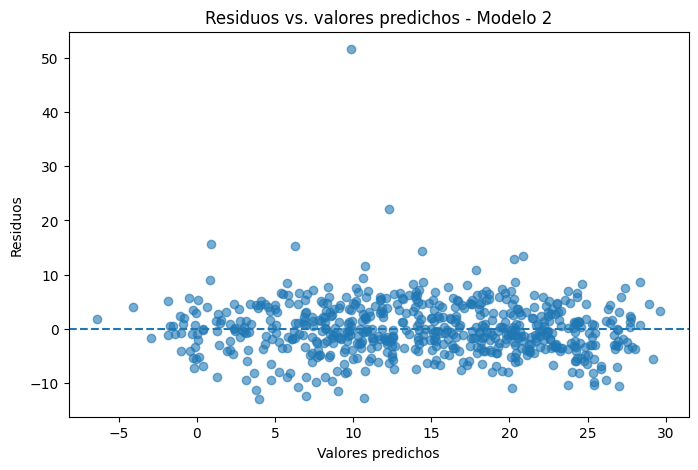

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_m2, residuos_m2, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs. valores predichos - Modelo 2")

plt.show()

### 7.1 - Prueba forma de linealidad

In [47]:
X_train_m2 = modelo_2.named_steps["ingenieria"].transform(X_train)

X_train_m2_preparado = modelo_2.named_steps["preprocesamiento"].transform(X_train_m2)

X_train_m2_preparado.shape


(1846, 33)

In [51]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_train_m2_preparado)
modelo_sm = sm.OLS(y_train, X_sm).fit()

from statsmodels.stats.diagnostic import linear_rainbow

rainbow_stat, rainbow_pvalue = linear_rainbow(modelo_sm)

print("Estadístico Rainbow:", rainbow_stat)
print("p-value:", rainbow_pvalue)

Estadístico Rainbow: 1.3360431277063507
p-value: 6.923865038354345e-06


### Supuesto de linealidad

Se aplicó la prueba Rainbow sobre el Modelo 2 para evaluar el supuesto de linealidad.

Se obtuvo un estadístico de 1.336 y un p-value de aproximadamente 0.000007. Dado que el p-value es menor que 0.05, se rechaza la hipótesis nula de linealidad.

Por lo tanto, existe evidencia estadística de que la relación entre las variables explicativas y la temperatura máxima del día siguiente no es completamente lineal.

Este resultado implica que la interpretación de los coeficientes del modelo debe realizarse con cautela, aunque el modelo puede seguir siendo útil desde el punto de vista predictivo.

### 7.2 - Independencia de los errores

In [52]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(modelo_sm.resid)

print("Durbin-Watson:", dw)

Durbin-Watson: 1.984702025381674


### Supuesto de independencia de los errores

Se utilizó el estadístico de Durbin-Watson para evaluar la posible autocorrelación de los residuos del Modelo 2.

El valor obtenido fue 1.985. Dado que este valor es muy cercano a 2, no se observa evidencia importante de autocorrelación positiva o negativa en los residuos.

Por lo tanto, el supuesto de independencia de los errores se considera razonablemente satisfecho.

### 7.3 - Homocedasticidad

In [53]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(modelo_sm.resid, modelo_sm.model.exog)

print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

LM Statistic: 77.7960808554375
LM p-value: 1.7599346640022698e-05
F Statistic: 2.415848098633787
F p-value: 1.3377008476264586e-05


### Supuesto de homocedasticidad

Se aplicó la prueba de Breusch-Pagan para evaluar si la varianza de los residuos permanece constante.

Se obtuvo un LM p-value de aproximadamente 0.000018 y un F p-value de aproximadamente 0.000013. Dado que ambos valores son menores que 0.05, se rechaza la hipótesis nula de homocedasticidad.

Por lo tanto, existe evidencia de heterocedasticidad en los residuos del Modelo 2, lo que indica que la variabilidad de los errores cambia según los valores de las variables explicativas.

Este incumplimiento debe tenerse en cuenta al interpretar estadísticamente los coeficientes del modelo.

### 7.4 - Normalidad

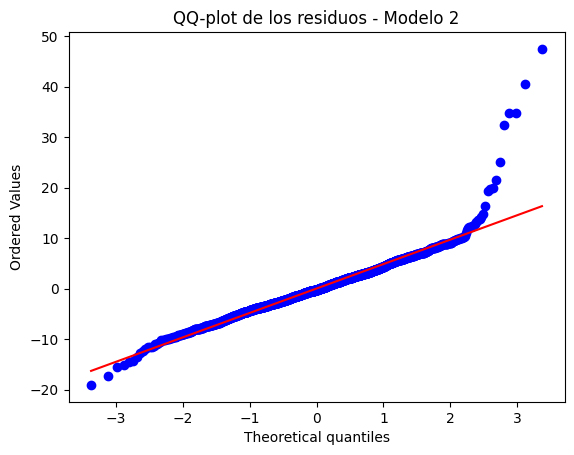

Estadístico Shapiro: 0.9272578002324668
p-value: 4.985153543271012e-29


In [54]:
from scipy import stats

stats.probplot(modelo_sm.resid, dist="norm", plot=plt)
plt.title("QQ-plot de los residuos - Modelo 2")
plt.show()

from scipy.stats import shapiro

shapiro_stat, shapiro_pvalue = shapiro(modelo_sm.resid)

print("Estadístico Shapiro:", shapiro_stat)
print("p-value:", shapiro_pvalue)

### Supuesto de normalidad de los residuos

Se evaluó la normalidad de los residuos mediante un QQ-plot y la prueba de Shapiro-Wilk.

En el QQ-plot se observa que los residuos siguen aproximadamente la línea teórica en la zona central, pero presentan desviaciones importantes en las colas, especialmente en la cola superior.

La prueba de Shapiro-Wilk produjo un estadístico de 0.927 y un p-value cercano a 0. Por lo tanto, dado que el p-value es menor que 0.05, se rechaza la hipótesis nula de normalidad.

En consecuencia, los residuos del Modelo 2 no presentan una distribución normal. Este resultado debe considerarse al realizar inferencia e interpretar los coeficientes del modelo.

### 7.5 VIF

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Variable"] = range(X_train_m2_preparado.shape[1])

vif["VIF"] = [
    variance_inflation_factor(X_train_m2_preparado, i)
    for i in range(X_train_m2_preparado.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Variable,VIF
21,21,9.812178
5,5,9.600297
7,7,9.350117
19,19,7.005921
18,18,6.191159
16,16,6.053804
9,9,5.175599
8,8,4.831113
15,15,2.834769
23,23,2.722588


### Supuesto de multicolinealidad

Se evaluó la multicolinealidad entre las variables explicativas mediante el Factor de Inflación de la Varianza (VIF).

Se observaron varias variables con valores de VIF elevados. En particular, algunas características presentan valores cercanos a 10 y otras superiores a 5.

Esto indica que existe multicolinealidad entre algunas de las variables utilizadas por el Modelo 2. Por lo tanto, los coeficientes individuales pueden ser inestables y su interpretación debe realizarse con cautela.

Sin embargo, la presencia de multicolinealidad no implica necesariamente que el modelo tenga un bajo desempeño predictivo, por lo que se mantiene el Modelo 2 como el modelo seleccionado con base en sus métricas de validación.

In [57]:
nombres_features = modelo_2.named_steps["preprocesamiento"].get_feature_names_out()

nombres_features

coeficientes_m2 = modelo_2.named_steps["modelo"].coef_

tabla_coeficientes = pd.DataFrame({
    "Variable": nombres_features,
    "Coeficiente": coeficientes_m2
})

tabla_coeficientes["Coeficiente_abs"] = tabla_coeficientes["Coeficiente"].abs()

tabla_coeficientes.sort_values(
    "Coeficiente_abs",
    ascending=False
).round(3)

,Variable,Coeficiente,Coeficiente_abs
24,cat__mes_calendario_enero,-9.492,9.492
25,cat__mes_calendario_febrero,-9.159,9.159
26,cat__mes_calendario_julio,9.110,9.110
22,cat__mes_calendario_agosto,8.404,8.404
27,cat__mes_calendario_junio,6.744,6.744
23,cat__mes_calendario_diciembre,-6.170,6.170
28,cat__mes_calendario_marzo,-4.666,4.666
17,cat__sector_viento_NO,-4.297,4.297
30,cat__mes_calendario_noviembre,-4.284,4.284
32,cat__mes_calendario_septiembre,4.172,4.172


### Interpretación de los coeficientes del Modelo 2

Para analizar la importancia de las variables se revisaron los coeficientes del Modelo 2. Las variables numéricas fueron estandarizadas antes del ajuste, por lo que la magnitud de sus coeficientes puede compararse entre ellas. Las variables categóricas fueron representadas mediante One-Hot Encoding, por lo que sus coeficientes se interpretan con respecto a la categoría de referencia omitida.

Los coeficientes asociados al mes del año presentan algunas de las mayores magnitudes del modelo, lo que sugiere que la estacionalidad es un componente importante en la predicción de la temperatura máxima del día siguiente.

Entre las variables numéricas, las de mayor magnitud son `viento_norte`, `humedad_desv`, `humedad_media`, `presion_media`, `rafaga_media` y `presion_desv`.

`viento_norte` presenta un coeficiente de -1.954, mientras que `humedad_desv` presenta un coeficiente de 1.383. Por su parte, `humedad_media` tiene un coeficiente de -0.758 y `presion_media` uno de 0.566.

Estos coeficientes representan asociaciones dentro del modelo y no deben interpretarse como relaciones causales. Además, debido al incumplimiento de varios supuestos de la regresión lineal y a la presencia de multicolinealidad, la interpretación individual de los coeficientes debe realizarse con cautela.

In [61]:
tabla_numericas = tabla_coeficientes[
    tabla_coeficientes["Variable"].str.startswith("num__")
].copy()

tabla_numericas = tabla_numericas.sort_values(
    "Coeficiente_abs",
    ascending=False
)

tabla_numericas.round(3)

,Variable,Coeficiente,Coeficiente_abs
8,num__viento_norte,-1.954,1.954
3,num__humedad_desv,1.383,1.383
2,num__humedad_media,-0.758,0.758
0,num__presion_media,0.566,0.566
6,num__rafaga_media,-0.490,0.490
1,num__presion_desv,-0.446,0.446
7,num__rafaga_desv,0.156,0.156
9,num__viento_este,0.149,0.149
5,num__viento_desv,0.134,0.134
4,num__viento_media,-0.125,0.125


In [62]:
tabla_categoricas = tabla_coeficientes[
    tabla_coeficientes["Variable"].str.startswith("cat__")
].copy()

tabla_categoricas = tabla_categoricas.sort_values(
    "Coeficiente_abs",
    ascending=False
)

tabla_categoricas.round(3)

,Variable,Coeficiente,Coeficiente_abs
24,cat__mes_calendario_enero,-9.492,9.492
25,cat__mes_calendario_febrero,-9.159,9.159
26,cat__mes_calendario_julio,9.110,9.110
22,cat__mes_calendario_agosto,8.404,8.404
27,cat__mes_calendario_junio,6.744,6.744
23,cat__mes_calendario_diciembre,-6.170,6.170
28,cat__mes_calendario_marzo,-4.666,4.666
17,cat__sector_viento_NO,-4.297,4.297
30,cat__mes_calendario_noviembre,-4.284,4.284
32,cat__mes_calendario_septiembre,4.172,4.172


### Conclusión sobre la importancia de las variables

Los coeficientes del Modelo 2 muestran que la estacionalidad tiene una influencia importante en la predicción, ya que varias categorías asociadas al mes presentan los coeficientes de mayor magnitud. En particular, enero y febrero tienen efectos negativos importantes, mientras que junio, julio y agosto presentan efectos positivos respecto a la categoría de referencia.

Entre las variables numéricas estandarizadas, las de mayor magnitud son `viento_norte`, `humedad_desv`, `humedad_media`, `presion_media`, `rafaga_media` y `presion_desv`, lo que sugiere que las condiciones de viento, humedad y presión aportan información relevante para predecir la temperatura máxima del día siguiente.

Sin embargo, estos coeficientes deben interpretarse con cautela, ya que el modelo presentó incumplimientos en algunos supuestos de regresión lineal y evidencia de multicolinealidad. Por lo tanto, los coeficientes se utilizan principalmente como una medida cualitativa de asociación e importancia dentro del modelo, y no como efectos causales.

## 8. Análisis e interpretación del modelo seleccionado

En esta sección se analiza con mayor detalle el Modelo 2, seleccionado como el mejor modelo a partir de las métricas de validación.

El objetivo es interpretar su representación matemática, revisar los coeficientes estimados, identificar las variables más relevantes para la predicción de `temp_max_manana` y relacionar estos resultados con el problema planteado.

Debido a que en la sección anterior se encontraron incumplimientos en algunos supuestos de la regresión lineal y evidencia de multicolinealidad, las interpretaciones de los coeficientes se realizarán con cautela y como asociaciones dentro del modelo, no como relaciones causales.

### 8.1 Representación matemática y coeficientes del Modelo 2

In [63]:
intercepto_m2 = modelo_2.named_steps["modelo"].intercept_
print("Intercepto:", intercepto_m2)

Intercepto: 16.874337217100948


In [67]:
encoder_pipeline = modelo_2.named_steps["preprocesamiento"].named_transformers_["cat"]
encoder = encoder_pipeline.named_steps["codificador"]

print("Categorías aprendidas:")
for categorias in encoder.categories_:
    print(categorias)

Categorías aprendidas:
['E' 'N' 'NE' 'NO' 'O' 'S' 'SE' 'SO']
['abril' 'agosto' 'diciembre' 'enero' 'febrero' 'julio' 'junio' 'marzo'
 'mayo' 'noviembre' 'octubre' 'septiembre']


### Representación del Modelo 2

El Modelo 2 utiliza una regresión lineal para predecir la temperatura máxima del día siguiente a partir de las variables meteorológicas seleccionadas.

El intercepto estimado del modelo es **16.874**.

Las variables numéricas fueron estandarizadas antes del ajuste, mientras que las variables categóricas se transformaron mediante One-Hot Encoding.

Como se utilizó `drop='first'`, las categorías de referencia son:

- `sector_viento = E`
- `mes_calendario = abril`

Por lo tanto, los coeficientes asociados a los demás sectores de viento y meses se interpretan en comparación con estas categorías de referencia, manteniendo las demás variables constantes.

Por ejemplo, `mes_calendario_enero` tiene un coeficiente de **-9.492**, lo que indica que enero se asocia con una temperatura máxima predicha aproximadamente **9.49 °C menor que abril**, manteniendo las demás variables constantes.

Por otro lado, `mes_calendario_julio` tiene un coeficiente de **9.110**, por lo que julio se asocia con una temperatura máxima predicha aproximadamente **9.11 °C mayor que abril**.

En las variables numéricas estandarizadas, el coeficiente representa el cambio esperado en la predicción cuando la variable aumenta una desviación estándar, manteniendo las demás variables constantes.

### 8.2 Desempeño y selección del mejor modelo

Para comparar los dos modelos se utilizaron las métricas RMSE, MAE y R² sobre el conjunto de validación.

El Modelo 1 obtuvo un RMSE de **5.594**, un MAE de **4.108** y un R² de **0.619**. Por su parte, el Modelo 2 obtuvo un RMSE de **5.014**, un MAE de **3.663** y un R² de **0.694**.

El Modelo 2 presenta menores errores tanto en RMSE como en MAE, lo que indica que sus predicciones se encuentran, en promedio, más cerca de los valores reales. Además, su mayor R² indica que explica una mayor proporción de la variabilidad de la temperatura máxima del día siguiente.

Por estas razones, se selecciona el **Modelo 2** como el modelo con mejor desempeño.

### 8.3 Variables seleccionadas e interpretación en el contexto del problema

El Modelo 2 utiliza información relacionada con **presión, humedad, viento, ráfagas, dirección del viento y estacionalidad** para predecir la temperatura máxima del día siguiente.

Entre las variables numéricas, las que presentan coeficientes de mayor magnitud son `viento_norte`, `humedad_desv`, `humedad_media`, `presion_media`, `rafaga_media` y `presion_desv`. Esto indica que las condiciones asociadas al viento, la humedad y la presión contienen información relevante para realizar la predicción.

Además, las variables asociadas al `mes_calendario` presentan algunos de los coeficientes de mayor magnitud de todo el modelo. Esto sugiere que la **estacionalidad** aporta información importante, ya que la temperatura máxima esperada cambia dependiendo de la época del año.

En el contexto del problema de AlpesPlanck, estas variables permiten identificar qué condiciones meteorológicas tienen mayor relación con la temperatura máxima del día siguiente. Esta información puede ser útil tanto para mejorar la capacidad predictiva del modelo como para comprender qué grupos de variables aportan más información a la estimación.

Sin embargo, debido a que algunos supuestos de la regresión lineal no se cumplen y existe evidencia de multicolinealidad, la importancia de las variables debe interpretarse como una asociación dentro del modelo y no como una relación causal.

### 8.4 Funcionamiento de la regresión lineal y proceso de construcción del modelo

La regresión lineal busca encontrar una combinación lineal de las variables de entrada que permita aproximar una variable numérica continua. Para esto, el algoritmo estima un conjunto de coeficientes que minimiza la suma de los errores cuadrados entre los valores reales y los valores predichos. En el curso este procedimiento se presenta mediante el enfoque analítico de mínimos cuadrados y también mediante optimización. :contentReference[oaicite:0]{index=0}

Para este laboratorio, primero se realizó la exploración y limpieza de los datos. Posteriormente, se separaron las variables explicativas de la variable objetivo `temp_max_manana` y se dividieron los datos en entrenamiento y validación.

La preparación de los datos se integró dentro de un `Pipeline` para evitar que operaciones como la imputación, el escalado y la codificación aprendieran información del conjunto de validación. Las variables numéricas se imputaron y estandarizaron, mientras que las categóricas se imputaron y transformaron mediante One-Hot Encoding. Este procedimiento sigue la estructura trabajada en la práctica de regresión lineal del curso. :contentReference[oaicite:1]{index=1}

Finalmente, se ajustaron dos modelos con `LinearRegression`. Sus predicciones se evaluaron mediante RMSE, MAE y R² sobre datos que no fueron utilizados para entrenar el modelo. A partir de esta comparación se seleccionó el Modelo 2, ya que presentó el mejor desempeño de generalización.

### 8.5 Posibles sesgos dentro del ciclo de Machine Learning

Uno de los posibles riesgos es el **sesgo de muestra**. El modelo fue entrenado con observaciones meteorológicas provenientes de una ubicación y un periodo determinados, por lo que los patrones aprendidos representan principalmente esas condiciones. Si los datos disponibles no representan adecuadamente otras épocas, condiciones meteorológicas menos frecuentes o contextos diferentes, el desempeño observado en validación podría no mantenerse al aplicar el modelo sobre datos con una distribución distinta.

Un segundo riesgo puede aparecer durante la **preparación y limpieza de los datos**. Decisiones como eliminar registros, imputar valores faltantes, corregir valores inconsistentes o transformar variables pueden modificar la distribución original de los datos. Si estas decisiones afectan de manera desproporcionada ciertos tipos de observaciones, el modelo puede terminar aprendiendo una representación sesgada del fenómeno.

Para reducir estos riesgos, durante el laboratorio se documentaron las decisiones de preparación, se conservaron únicamente correcciones justificadas por el análisis de calidad y las transformaciones que aprenden parámetros se ajustaron únicamente con los datos de entrenamiento.

## 9. Predicción sobre el conjunto de test final

Una vez seleccionado el Modelo 2 a partir del conjunto de validación, se utilizará para generar las predicciones de `temp_max_manana` sobre el conjunto de datos de test proporcionado para el laboratorio.

Antes de realizar las predicciones se verifica que el conjunto de test contenga las mismas variables de entrada requeridas por el modelo. Este conjunto no se utiliza para evaluar, seleccionar ni ajustar decisiones de preparación durante el desarrollo de los modelos.

In [68]:
print("Forma de X:", X.shape)
print("Forma de datos_test:", datos_test.shape)

print("\nColumnas que están en X pero no en datos_test:")
print(set(X.columns) - set(datos_test.columns))

print("\nColumnas que están en datos_test pero no en X:")
print(set(datos_test.columns) - set(X.columns))

Forma de X: (2462, 24)
Forma de datos_test: (364, 26)

Columnas que están en X pero no en datos_test:
set()

Columnas que están en datos_test pero no en X:
{'anio', 'fecha'}


In [69]:
X_test_final = datos_test[X.columns].copy()

print(X_test_final.shape)

(364, 24)


In [70]:
predicciones_test = modelo_2.predict(X_test_final)

print("Número de predicciones:", len(predicciones_test))
print(predicciones_test[:10])

Número de predicciones: 364
[ 3.22897999  0.43238209  2.85853332  3.43232513 -2.0334989  -3.56890245
  1.3518805   4.67373991  2.60772105  3.83369435]


In [71]:
pd.Series(predicciones_test).isna().sum()

0

In [72]:
datos_test_entrega = datos_test.copy()

datos_test_entrega["temp_max_manana"] = predicciones_test

datos_test_entrega.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,sector_viento,mes_calendario,estacion,temp_max_manana
0,2016-01-01,998.9860,995.57,1000.60,1.1082,96.1493,90.8,98.7,2.0034,0.9649,...,-0.8328,0.0927,173.6501,144,2016,1,S,enero,invierno,3.228980
1,2016-01-02,991.4241,989.27,995.51,1.9413,92.3236,85.8,96.8,2.6562,1.9886,...,1.1161,0.6688,30.9301,144,2016,2,NE,enero,invierno,0.432382
2,2016-01-03,984.0232,974.12,989.39,4.5841,83.6056,73.9,94.7,6.9967,2.4992,...,-0.7923,1.2638,122.0847,144,2016,3,SE,enero,invierno,2.858533
3,2016-01-04,968.2449,966.52,974.02,1.9034,85.4688,75.5,93.8,5.8148,2.0932,...,-1.6217,0.7020,156.5944,144,2016,4,SE,enero,invierno,3.432325
4,2016-01-05,970.0099,967.85,972.90,1.6668,94.3521,92.0,96.8,1.4253,1.8380,...,1.6549,0.7109,23.2458,144,2016,5,NE,enero,invierno,-2.033499


In [74]:
datos_test_entrega.to_csv(
    "Datos test Lab1.csv",
    index=False
)

### Exportación de las predicciones

Se generaron predicciones para las 364 observaciones del conjunto de test utilizando el Modelo 2 seleccionado previamente.

Las predicciones se agregaron al conjunto de test original en la columna `temp_max_manana`, conservando las demás variables y el orden de las observaciones.

El archivo resultante se exportó en formato CSV como `Datos test Lab1.csv`, sin incluir una columna adicional correspondiente al índice del DataFrame.

## 10. Uso de herramientas de IA generativa

### 10.1 Declaración de uso

Durante el desarrollo del laboratorio se utilizó **ChatGPT (OpenAI)** como herramienta de apoyo.

Su uso se concentró principalmente en:

- aclaración de conceptos relacionados con regresión lineal, métricas y verificación de supuestos;
- apoyo en la depuración de errores de implementación;
- revisión de la estructura del análisis;
- generación inicial de fragmentos de código que posteriormente fueron revisados y adaptados;
- apoyo en la redacción de interpretaciones y conclusiones a partir de los resultados obtenidos.

Las decisiones relacionadas con la preparación de los datos, selección de variables, construcción de los modelos y selección del modelo final fueron revisadas por los integrantes del grupo a partir de los conceptos y prácticas trabajados en clase.

### 10.2 Prompts principales utilizados

Algunos de los prompts que influyeron directamente en el desarrollo del laboratorio fueron:

1. **Preparación de datos:**  
   "Revisa que la preparación de los datos esté alineada con las prácticas de clase y ten en cuenta errores como data leakage o repetición de información."

2. **Evaluación de modelos:**  
   "¿Cómo comparo los dos modelos de regresión lineal utilizando RMSE, MAE y R², siguiendo lo visto en clase?"

3. **Verificación de supuestos:**  
   "Ayúdame a verificar paso a paso los supuestos del mejor modelo utilizando las pruebas empleadas en la práctica de clase."

4. **Depuración:**  
   "El código genera un error al intentar acceder al OneHotEncoder dentro del pipeline. ¿Cómo puedo identificar correctamente el paso y acceder a sus categorías?"
   

### 10.3 Análisis crítico del resultado

**¿Qué partes del contenido generado fueron correctas y útiles?**

La herramienta fue especialmente útil para organizar el procedimiento de evaluación de los modelos, recordar la interpretación de las métricas RMSE, MAE y R², y estructurar las pruebas de los supuestos de regresión lineal. También fue útil para identificar y corregir errores relacionados con la estructura de los `Pipeline` y los nombres de sus pasos.

**¿Qué errores, imprecisiones o limitaciones se identificaron?**

Algunas respuestas iniciales asumieron nombres específicos para los pasos internos del `Pipeline`, como el nombre del transformador de ingeniería de características o del `OneHotEncoder`. Estos nombres no coincidían con nuestra implementación y generaron errores de tipo `KeyError` y `AttributeError`.

Por esta razón, en lugar de utilizar directamente el código propuesto, se inspeccionaron objetos como `modelo_2.named_steps` y los pasos internos del preprocesamiento para recuperar los nombres reales utilizados en el notebook. A partir de esta verificación se modificó el código antes de continuar.

También se evitó utilizar técnicas que todavía no habían sido trabajadas en el curso, priorizando las herramientas utilizadas en las prácticas proporcionadas por los profesores.

**¿Qué conceptos del curso permitieron evaluar o mejorar las respuestas generadas?**

Los conceptos de separación entre entrenamiento y validación, prevención de `data leakage`, uso de `Pipeline`, métricas de regresión, estandarización, One-Hot Encoding y verificación de supuestos permitieron evaluar si las sugerencias eran coherentes con la metodología desarrollada en clase.

### 10.4 Aportes propios de los estudiantes

Los integrantes del grupo realizaron directamente la exploración y diagnóstico de calidad de los datos, analizaron las inconsistencias encontradas y tomaron las decisiones finales de limpieza y preparación.

También se definieron y compararon las estrategias utilizadas en los dos modelos de regresión lineal, se ejecutaron todas las pruebas y se verificaron sus resultados antes de incorporarlos al análisis.

Las recomendaciones de la herramienta de IA fueron adaptadas a la estructura real del notebook y contrastadas con las prácticas y presentaciones del curso. En particular, se corrigieron fragmentos de código que asumían nombres incorrectos dentro de los `Pipeline`, se decidió mantener la separación entrenamiento-validación antes de las transformaciones que aprenden parámetros y se interpretaron los resultados obtenidos a partir de las salidas reales del modelo.

El principal aprendizaje del proceso fue que la IA puede facilitar la depuración y organización del análisis, pero las decisiones sobre calidad de datos, preparación, interpretación de métricas y validez de los resultados requieren comprender el problema y verificar cada resultado con los conceptos del curso.